
# Entrega 1 - Reprodução AlphaTensor-Quantum e análise Clifford/non-Clifford

Este notebook reproduz a parte localmente factível da Entrega 1 do projeto **AlphaTensor-Quantum, Clifford Splitting e Hibridização Estrutural**.

O objetivo aqui não é retreinar o AlphaTensor-Quantum completo. A reprodução fiel usa as decomposições oficiais publicadas pelo DeepMind, valida essas decomposições por igualdade tensorial e recalcula o T-count efetivo com gadgets. Em seguida, o notebook consolida os baselines práticos em QASM, as métricas estruturais Clifford/non-Clifford e as figuras que entram no primeiro draft do relatório.



## 1. Setup

A célula abaixo configura paths, importa a camada reutilizável `atq_repro`, registra versões relevantes e confirma que estamos executando dentro de `project/`.


In [1]:

from pathlib import Path
import importlib.metadata as metadata
import json
import shutil
import subprocess
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

start_dir = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in (start_dir, *start_dir.parents):
    if (candidate / "pyproject.toml").exists() and (candidate / "src" / "atq_repro").exists():
        PROJECT_ROOT = candidate
        break

assert PROJECT_ROOT is not None, f"Nao encontrei a raiz project/ a partir de {start_dir}"

for path in (PROJECT_ROOT / "src", PROJECT_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from atq_repro.io import available_decomposition_families
from atq_repro.paper import reproduce_paper_results
from atq_repro.paths import DECOMPOSITIONS_ROOT, BENCHMARKS_ROOT, PAPER_REPRO_ROOT, RESULTS_ROOT

versions = {}
for package in ["python", "numpy", "pandas", "matplotlib", "qiskit", "pyzx", "nbformat"]:
    if package == "python":
        versions[package] = sys.version.split()[0]
    else:
        try:
            versions[package] = metadata.version(package)
        except metadata.PackageNotFoundError:
            versions[package] = "not-installed"

print("Project root:", PROJECT_ROOT)
print(json.dumps(versions, indent=2))


Project root: /Users/caio/Deep-Learning/project
{
  "python": "3.11.14",
  "numpy": "2.2.6",
  "pandas": "3.0.2",
  "matplotlib": "3.10.8",
  "qiskit": "2.3.1",
  "pyzx": "0.10.0",
  "nbformat": "5.10.4"
}



## 2. Inventário local

A reprodução depende de dois tipos de artefatos vendorizados:

- benchmarks compilados de `circuit-to-tensor`, contendo os tensores alvo `.tensor.npy`;
- decomposições oficiais `.npz` do AlphaTensor-Quantum.


In [2]:

families = available_decomposition_families()
family_rows = []
for family in families:
    npz_path = DECOMPOSITIONS_ROOT / family.file_name
    family_rows.append({
        "arquivo_npz": family.file_name,
        "metodo": family.method,
        "familia": family.family_label,
        "usa_gadgets": family.use_gadgets,
        "existe": npz_path.exists(),
        "tamanho_mb": round(npz_path.stat().st_size / 1_000_000, 3) if npz_path.exists() else None,
    })

inventory_df = pd.DataFrame(family_rows)
display(inventory_df)

num_tensor_files = len(list(BENCHMARKS_ROOT.rglob("*.tensor.npy")))
num_qasm_files = len(list(BENCHMARKS_ROOT.rglob("*.qasm")))
print(f"Tensores alvo encontrados: {num_tensor_files}")
print(f"QASM de benchmark encontrados: {num_qasm_files}")


,arquivo_npz,metodo,familia,usa_gadgets,existe,tamanho_mb
0,benchmarks_gadgets.npz,paper_gadgets,benchmark,True,True,0.210
1,benchmarks_no_gadgets.npz,paper_no_gadgets,benchmark,False,True,0.143
2,binary_addition.npz,paper_gadgets,binary_addition,True,True,0.003
3,hamming_weight_phase_gradient.npz,paper_gadgets,hamming_weight_phase_gradient,True,True,0.008
4,multiplication_finite_fields_gadgets.npz,paper_gadgets,finite_field_multiplication,True,True,0.030
5,multiplication_finite_fields_no_gadgets.npz,paper_no_gadgets,finite_field_multiplication,False,True,0.013
6,quantum_chemistry.npz,paper_gadgets,quantum_chemistry,True,True,0.035
7,unary_iteration_gadgets.npz,paper_gadgets,unary_iteration,True,True,0.016
8,unary_iteration_no_gadgets.npz,paper_no_gadgets,unary_iteration,False,True,0.011


Tensores alvo encontrados: 99
QASM de benchmark encontrados: 422



## 3. Reprodução fiel dos resultados do artigo

Esta é a camada principal para a Entrega 1. O notebook:

1. carrega cada decomposição oficial `.npz`;
2. mapeia a chave da decomposição para o tensor alvo `.tensor.npy`;
3. reconstrói o tensor assinatura por soma de fatores rank-1 em GF(2);
4. valida igualdade tensorial;
5. detecta padrões de gadgets Toffoli/CS quando a família usa gadgets;
6. calcula o T-count efetivo do artigo: `2 * n_toffoli + 2 * n_cs + n_t_remaining`;
7. compara com os valores reportados no artigo.


In [3]:

paper_paths = reproduce_paper_results(PAPER_REPRO_ROOT)
print(json.dumps({key: str(value.relative_to(PROJECT_ROOT)) if value.is_relative_to(PROJECT_ROOT) else str(value) for key, value in paper_paths.items()}, indent=2))


{
  "paper_results_long_csv": "results/reproducibility/paper/paper_results_long.csv",
  "paper_tensor_validation_csv": "results/reproducibility/paper/paper_tensor_validation.csv",
  "paper_benchmark_comparison_csv": "results/reproducibility/paper/paper_benchmark_comparison.csv",
  "paper_family_summary_csv": "results/reproducibility/paper/paper_family_summary.csv",
  "paper_aggregate_best_csv": "results/reproducibility/paper/paper_aggregate_best.csv",
  "paper_summary_json": "results/reproducibility/paper/paper_summary.json",
  "paper_reproduction_report": "results/reports/paper_reproduction_summary.md",
  "figure_benchmark_comparison": "results/reproducibility/paper/figures/paper_benchmark_comparison.png",
  "figure_gf_multiplication": "results/reproducibility/paper/figures/gf_multiplication_effective_tcount.png",
  "figure_binary_addition": "results/reproducibility/paper/figures/binary_addition_effective_tcount.png",
  "figure_family_coverage": "results/reproducibility/paper/figures/

In [4]:

comparison_df = pd.read_csv(paper_paths["paper_benchmark_comparison_csv"])
validation_df = pd.read_csv(paper_paths["paper_tensor_validation_csv"])
family_summary_df = pd.read_csv(paper_paths["paper_family_summary_csv"])

comparison_df["match"] = comparison_df["match"].astype(str).str.lower() == "true"
comparison_df["all_tensor_equal"] = comparison_df["all_tensor_equal"].astype(str).str.lower() == "true"

num_matches = int(comparison_df["match"].sum())
num_rows = len(comparison_df)
num_tensor_ok = int(comparison_df["all_tensor_equal"].sum())

print(f"Matches exatos com o artigo: {num_matches}/{num_rows}")
print(f"Linhas com decomposições selecionadas validadas tensorialmente: {num_tensor_ok}/{num_rows}")

assert num_matches == num_rows, "Há divergências de T-count efetivo na comparação com o artigo."
assert num_tensor_ok == num_rows, "Há decomposições selecionadas sem igualdade tensorial."

display(comparison_df.head(12))


Matches exatos com o artigo: 96/96
Linhas com decomposições selecionadas validadas tensorialmente: 96/96


,source,family_file,method,circuit_id,paper_effective_tcount,reproduced_effective_tcount,delta,match,all_tensor_equal,best_decomposition_keys,best_candidate_indices
0,paper_table_benchmark_no_gadgets,benchmarks_no_gadgets.npz,paper_no_gadgets,8_bit_adder,139,139,0,True,True,8_bit_adder_block1;8_bit_adder_block2,0;0
1,paper_table_benchmark_no_gadgets,benchmarks_no_gadgets.npz,paper_no_gadgets,barenco_tof_10,83,83,0,True,True,barenco_toff_10,0
2,paper_table_benchmark_no_gadgets,benchmarks_no_gadgets.npz,paper_no_gadgets,barenco_tof_3,13,13,0,True,True,barenco_toff_3,0
3,paper_table_benchmark_no_gadgets,benchmarks_no_gadgets.npz,paper_no_gadgets,barenco_tof_4,23,23,0,True,True,barenco_toff_4,0
4,paper_table_benchmark_no_gadgets,benchmarks_no_gadgets.npz,paper_no_gadgets,barenco_tof_5,33,33,0,True,True,barenco_toff_5,0
5,paper_table_benchmark_no_gadgets,benchmarks_no_gadgets.npz,paper_no_gadgets,csla_mux_3,39,39,0,True,True,csla_mux_3,0
6,paper_table_benchmark_no_gadgets,benchmarks_no_gadgets.npz,paper_no_gadgets,csum_mux_9,71,71,0,True,True,csum_mux_9,0
7,paper_table_benchmark_no_gadgets,benchmarks_no_gadgets.npz,paper_no_gadgets,grover_5,152,152,0,True,True,grover_5_block1;grover_5_block2,0;0
8,paper_table_benchmark_no_gadgets,benchmarks_no_gadgets.npz,paper_no_gadgets,hamming_15_high,773,773,0,True,True,hamming_15_high_block1;hamming_15_high_block2;...,0;0;0;0;0;0;0;0;0
9,paper_table_benchmark_no_gadgets,benchmarks_no_gadgets.npz,paper_no_gadgets,hamming_15_low,73,73,0,True,True,hamming_15_low,0



## 4. Cobertura por família

A tabela abaixo resume quantas chaves/candidatos foram auditados em cada família oficial. Isso ajuda a escrever a seção de Experimentos sem dar a impressão de que estamos apenas rodando exemplos pontuais.


In [5]:

display(family_summary_df)

validation_status = validation_df["tensor_equal"].astype(str).str.lower().value_counts(dropna=False)
print(validation_status)


,family_file,family_label,method,num_decomposition_keys,num_candidates,num_circuits,num_best_totals,num_tensor_equal_candidates,num_missing_tensor_candidates,mean_best_effective_tcount
0,benchmarks_gadgets.npz,benchmark,paper_gadgets,48,366,26,26,366,0,65.384615
1,benchmarks_no_gadgets.npz,benchmark,paper_no_gadgets,48,392,26,26,392,0,117.576923
2,binary_addition.npz,binary_addition,paper_gadgets,8,8,8,8,8,0,11.000000
3,hamming_weight_phase_gradient.npz,hamming_weight_phase_gradient,paper_gadgets,17,17,17,17,17,0,19.529412
4,multiplication_finite_fields_gadgets.npz,finite_field_multiplication,paper_gadgets,9,82,9,9,82,0,40.222222
5,multiplication_finite_fields_no_gadgets.npz,finite_field_multiplication,paper_no_gadgets,9,53,9,9,53,0,89.444444
6,quantum_chemistry.npz,quantum_chemistry,paper_gadgets,7,60,7,7,60,0,29.142857
7,unary_iteration_gadgets.npz,unary_iteration,paper_gadgets,3,30,3,3,30,0,35.333333
8,unary_iteration_no_gadgets.npz,unary_iteration,paper_no_gadgets,3,30,3,3,30,0,73.666667


tensor_equal
true    1038
Name: count, dtype: int64



## 5. Figuras da reprodução do paper

As figuras abaixo são geradas automaticamente a partir dos CSVs da reprodução tensorial.


### paper_benchmark_comparison.png

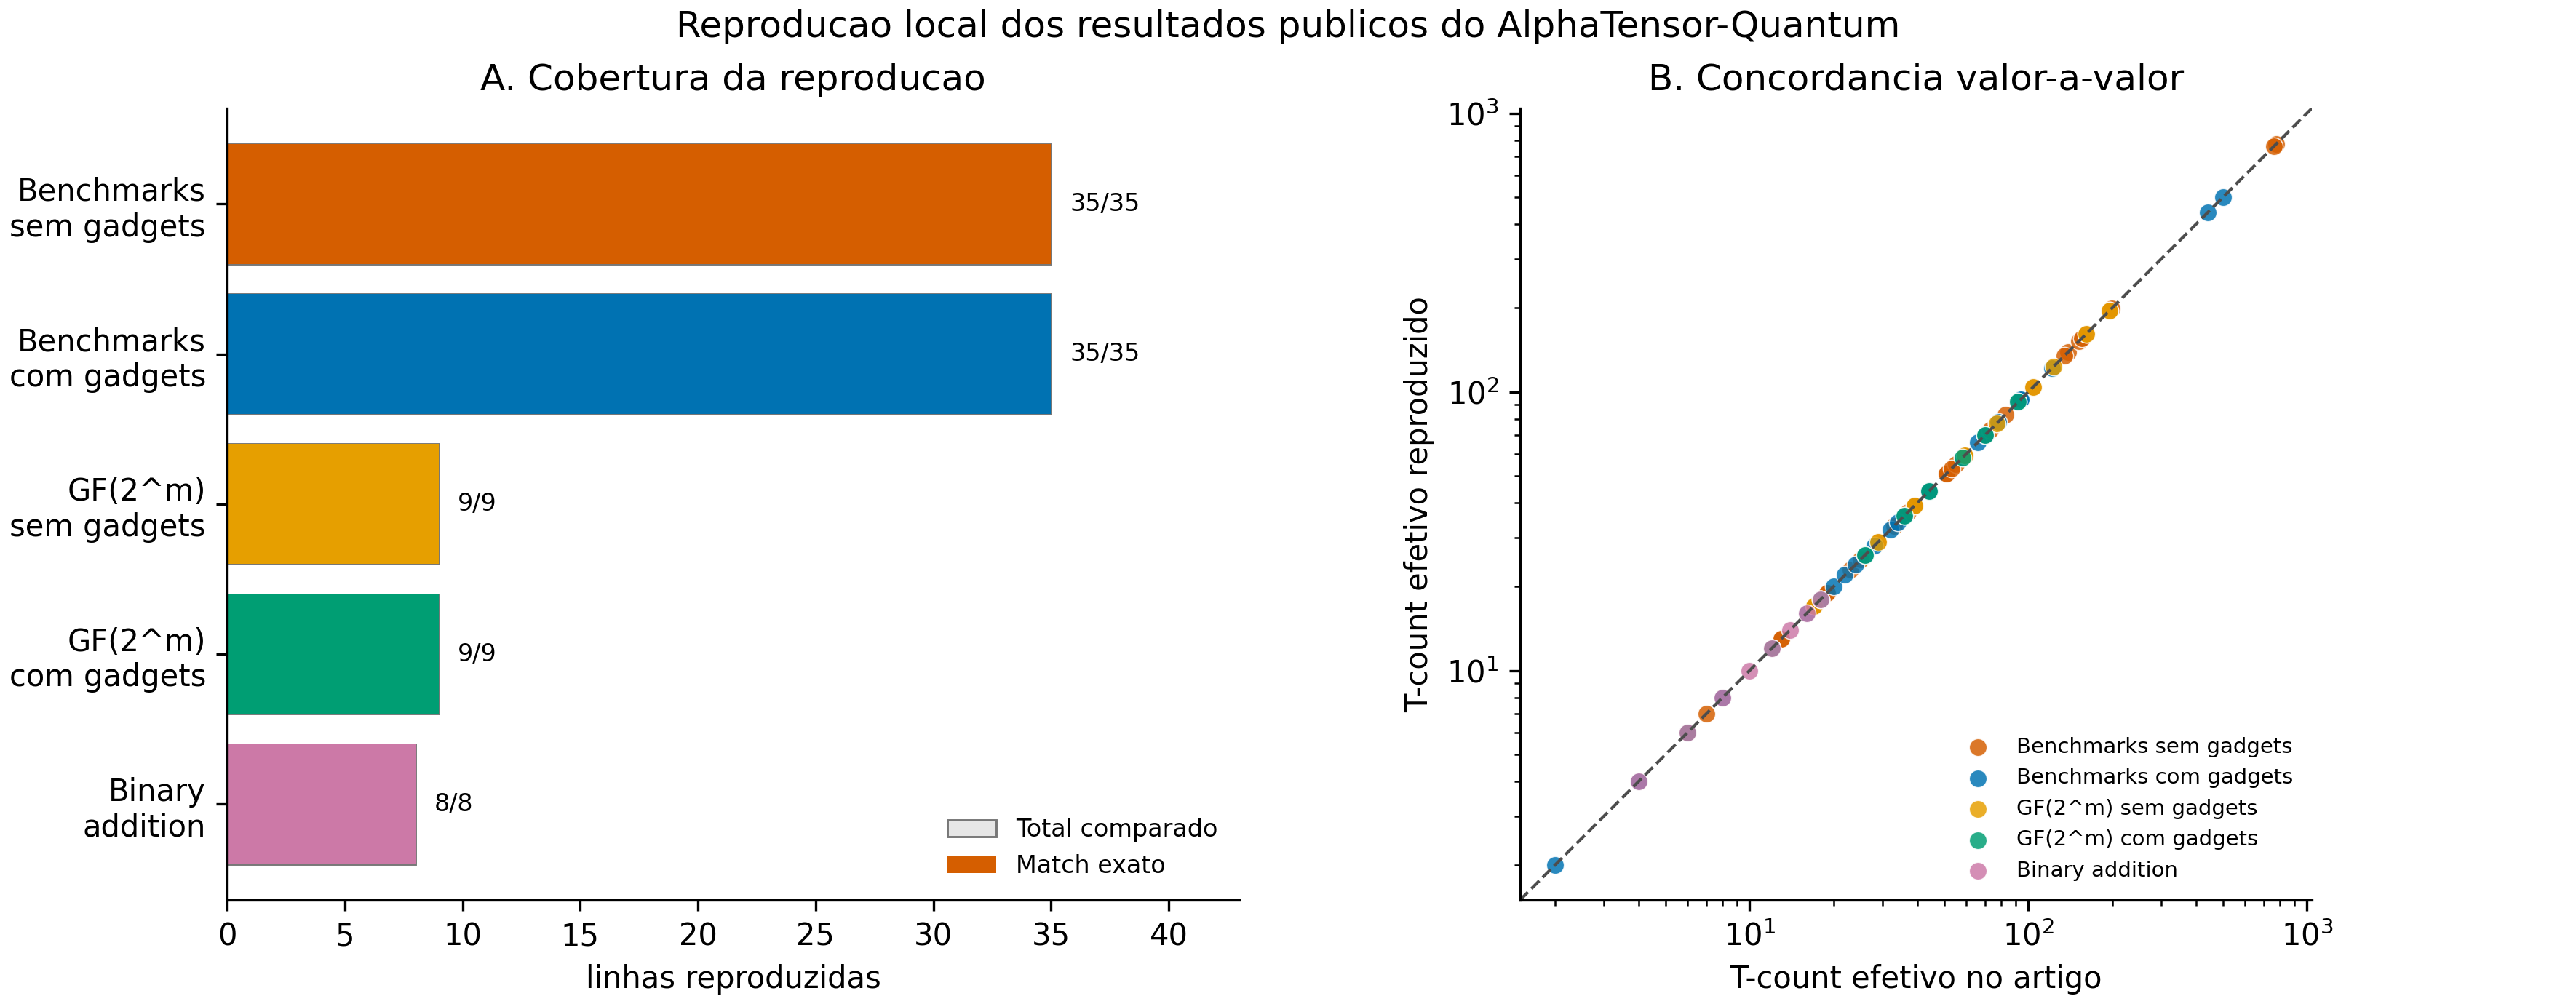

### gf_multiplication_effective_tcount.png

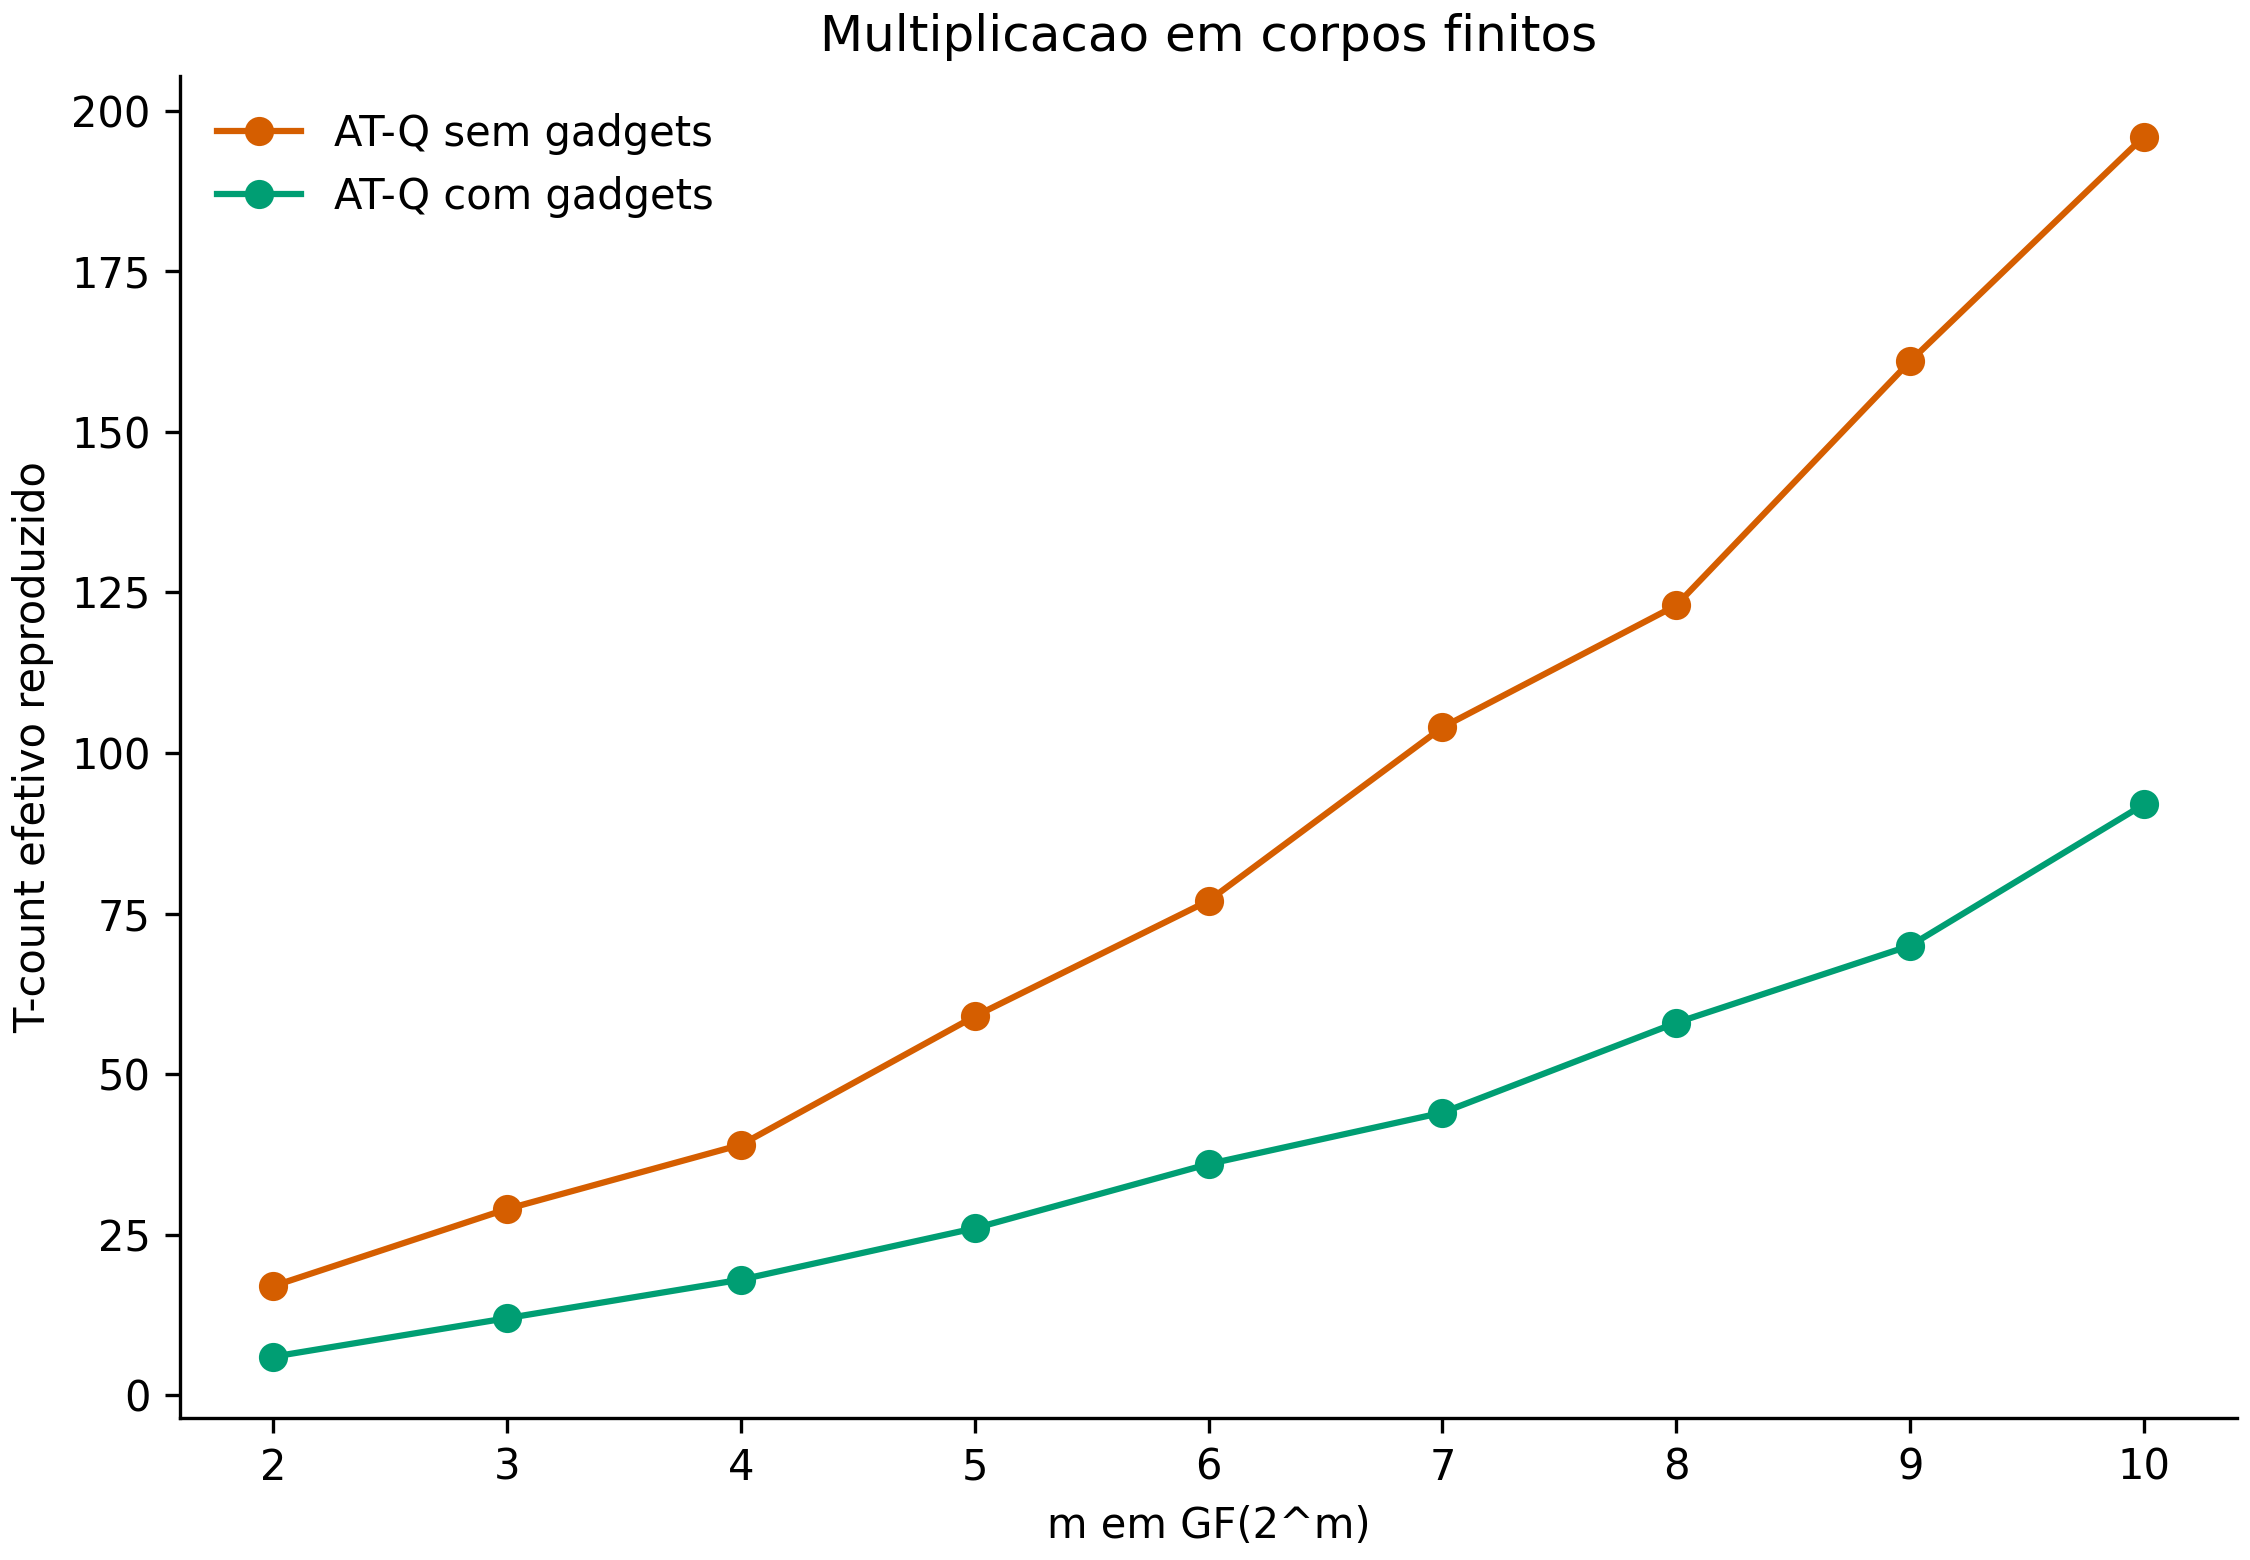

### binary_addition_effective_tcount.png

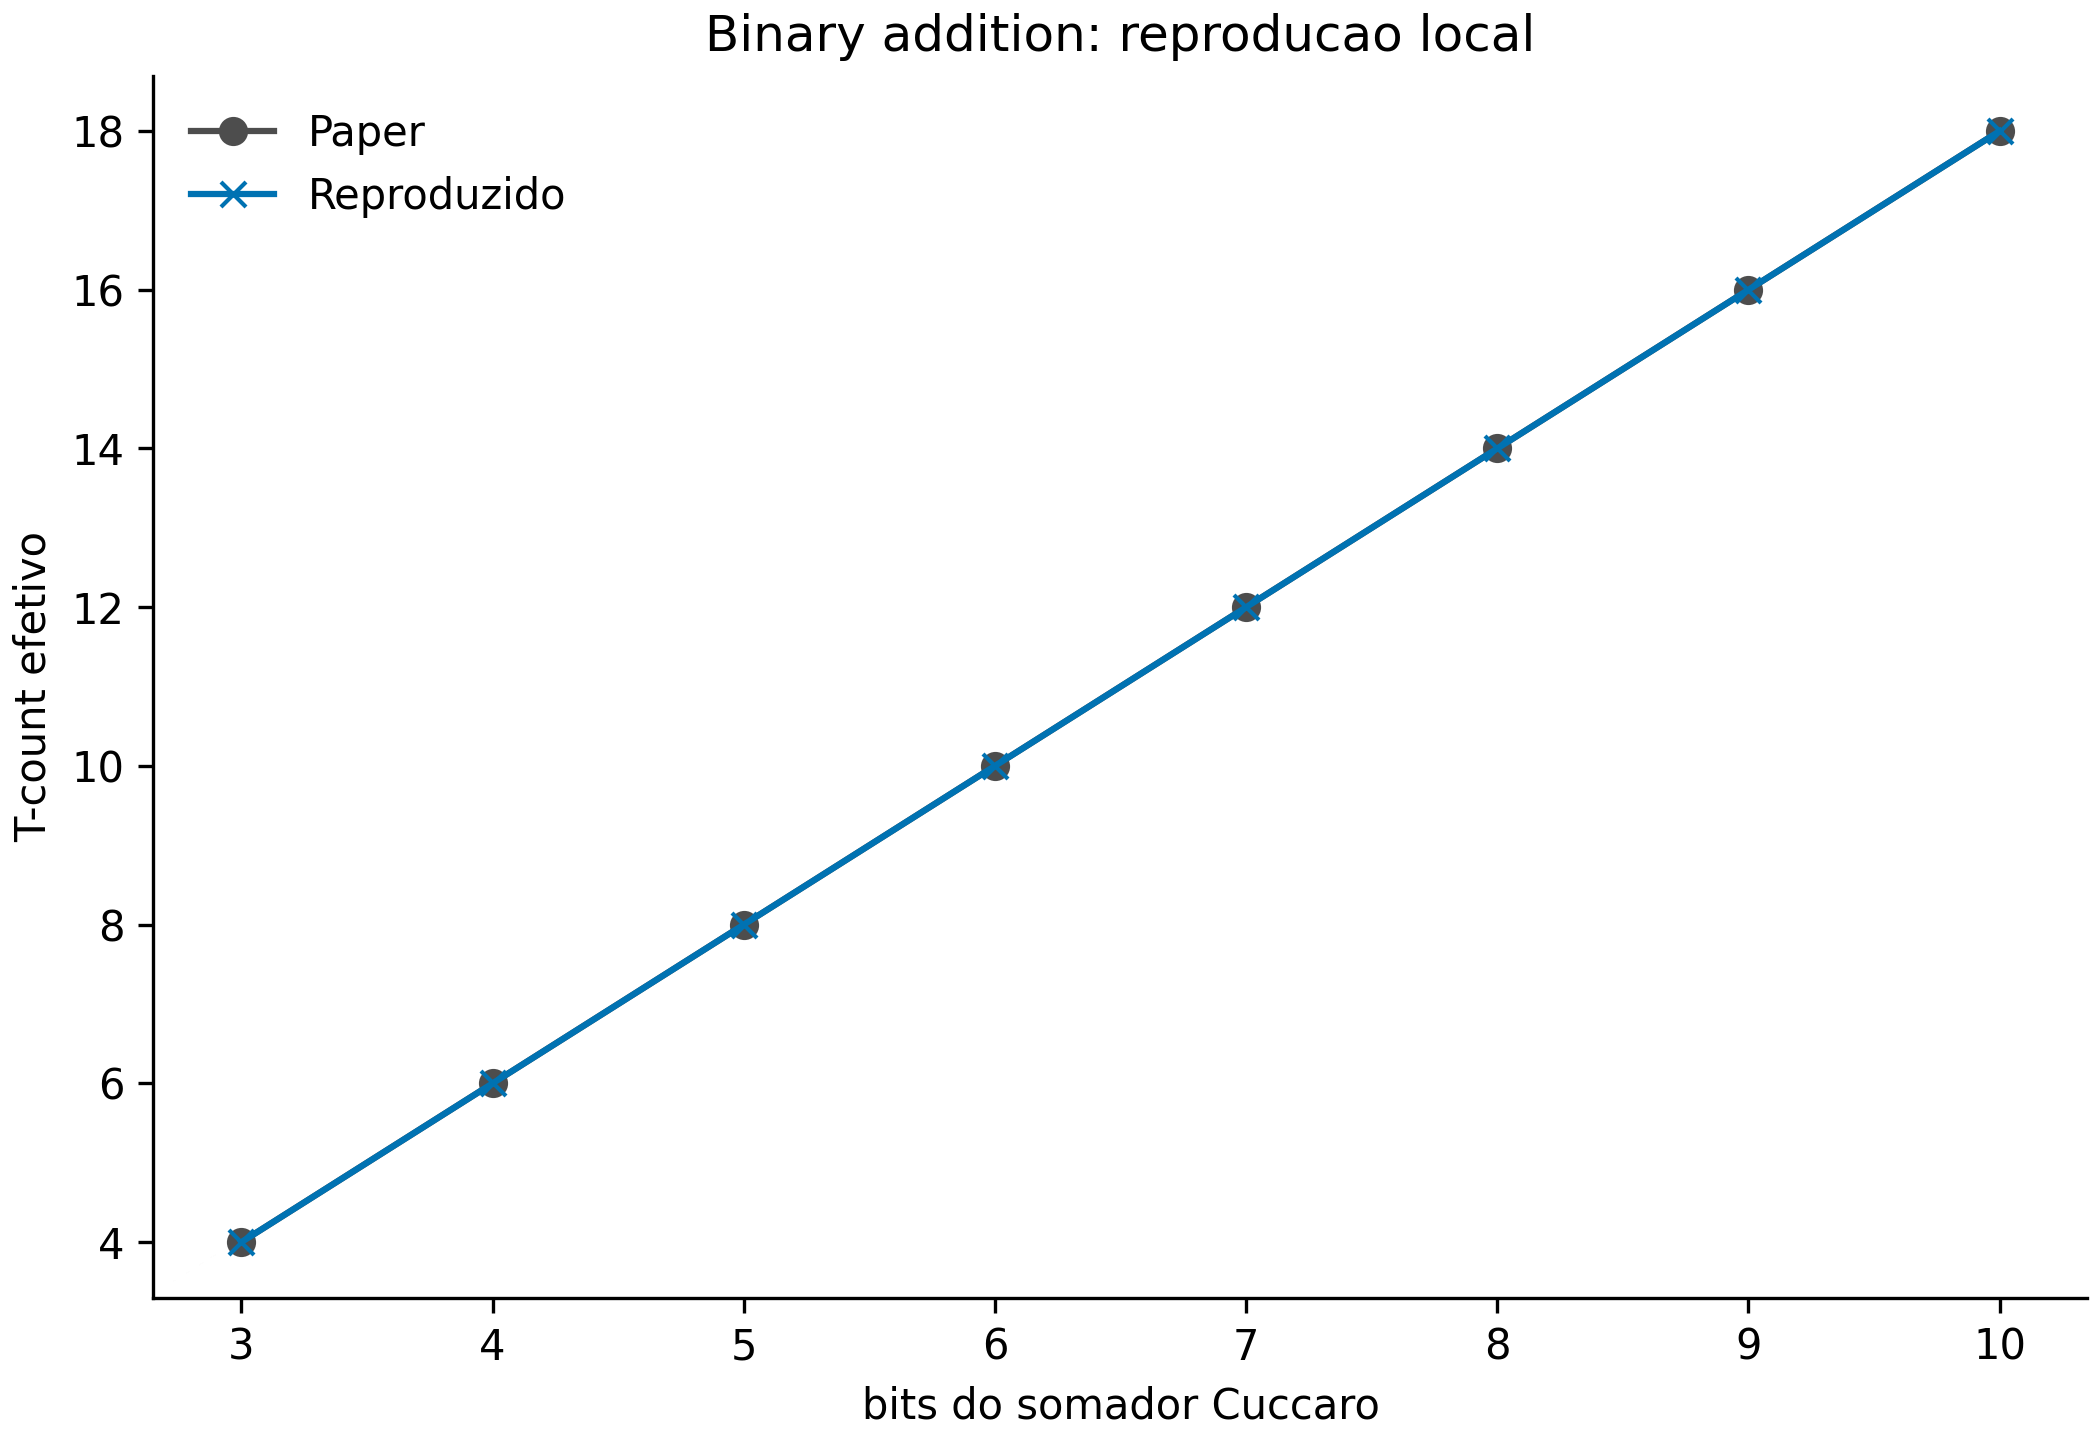

### paper_family_coverage.png

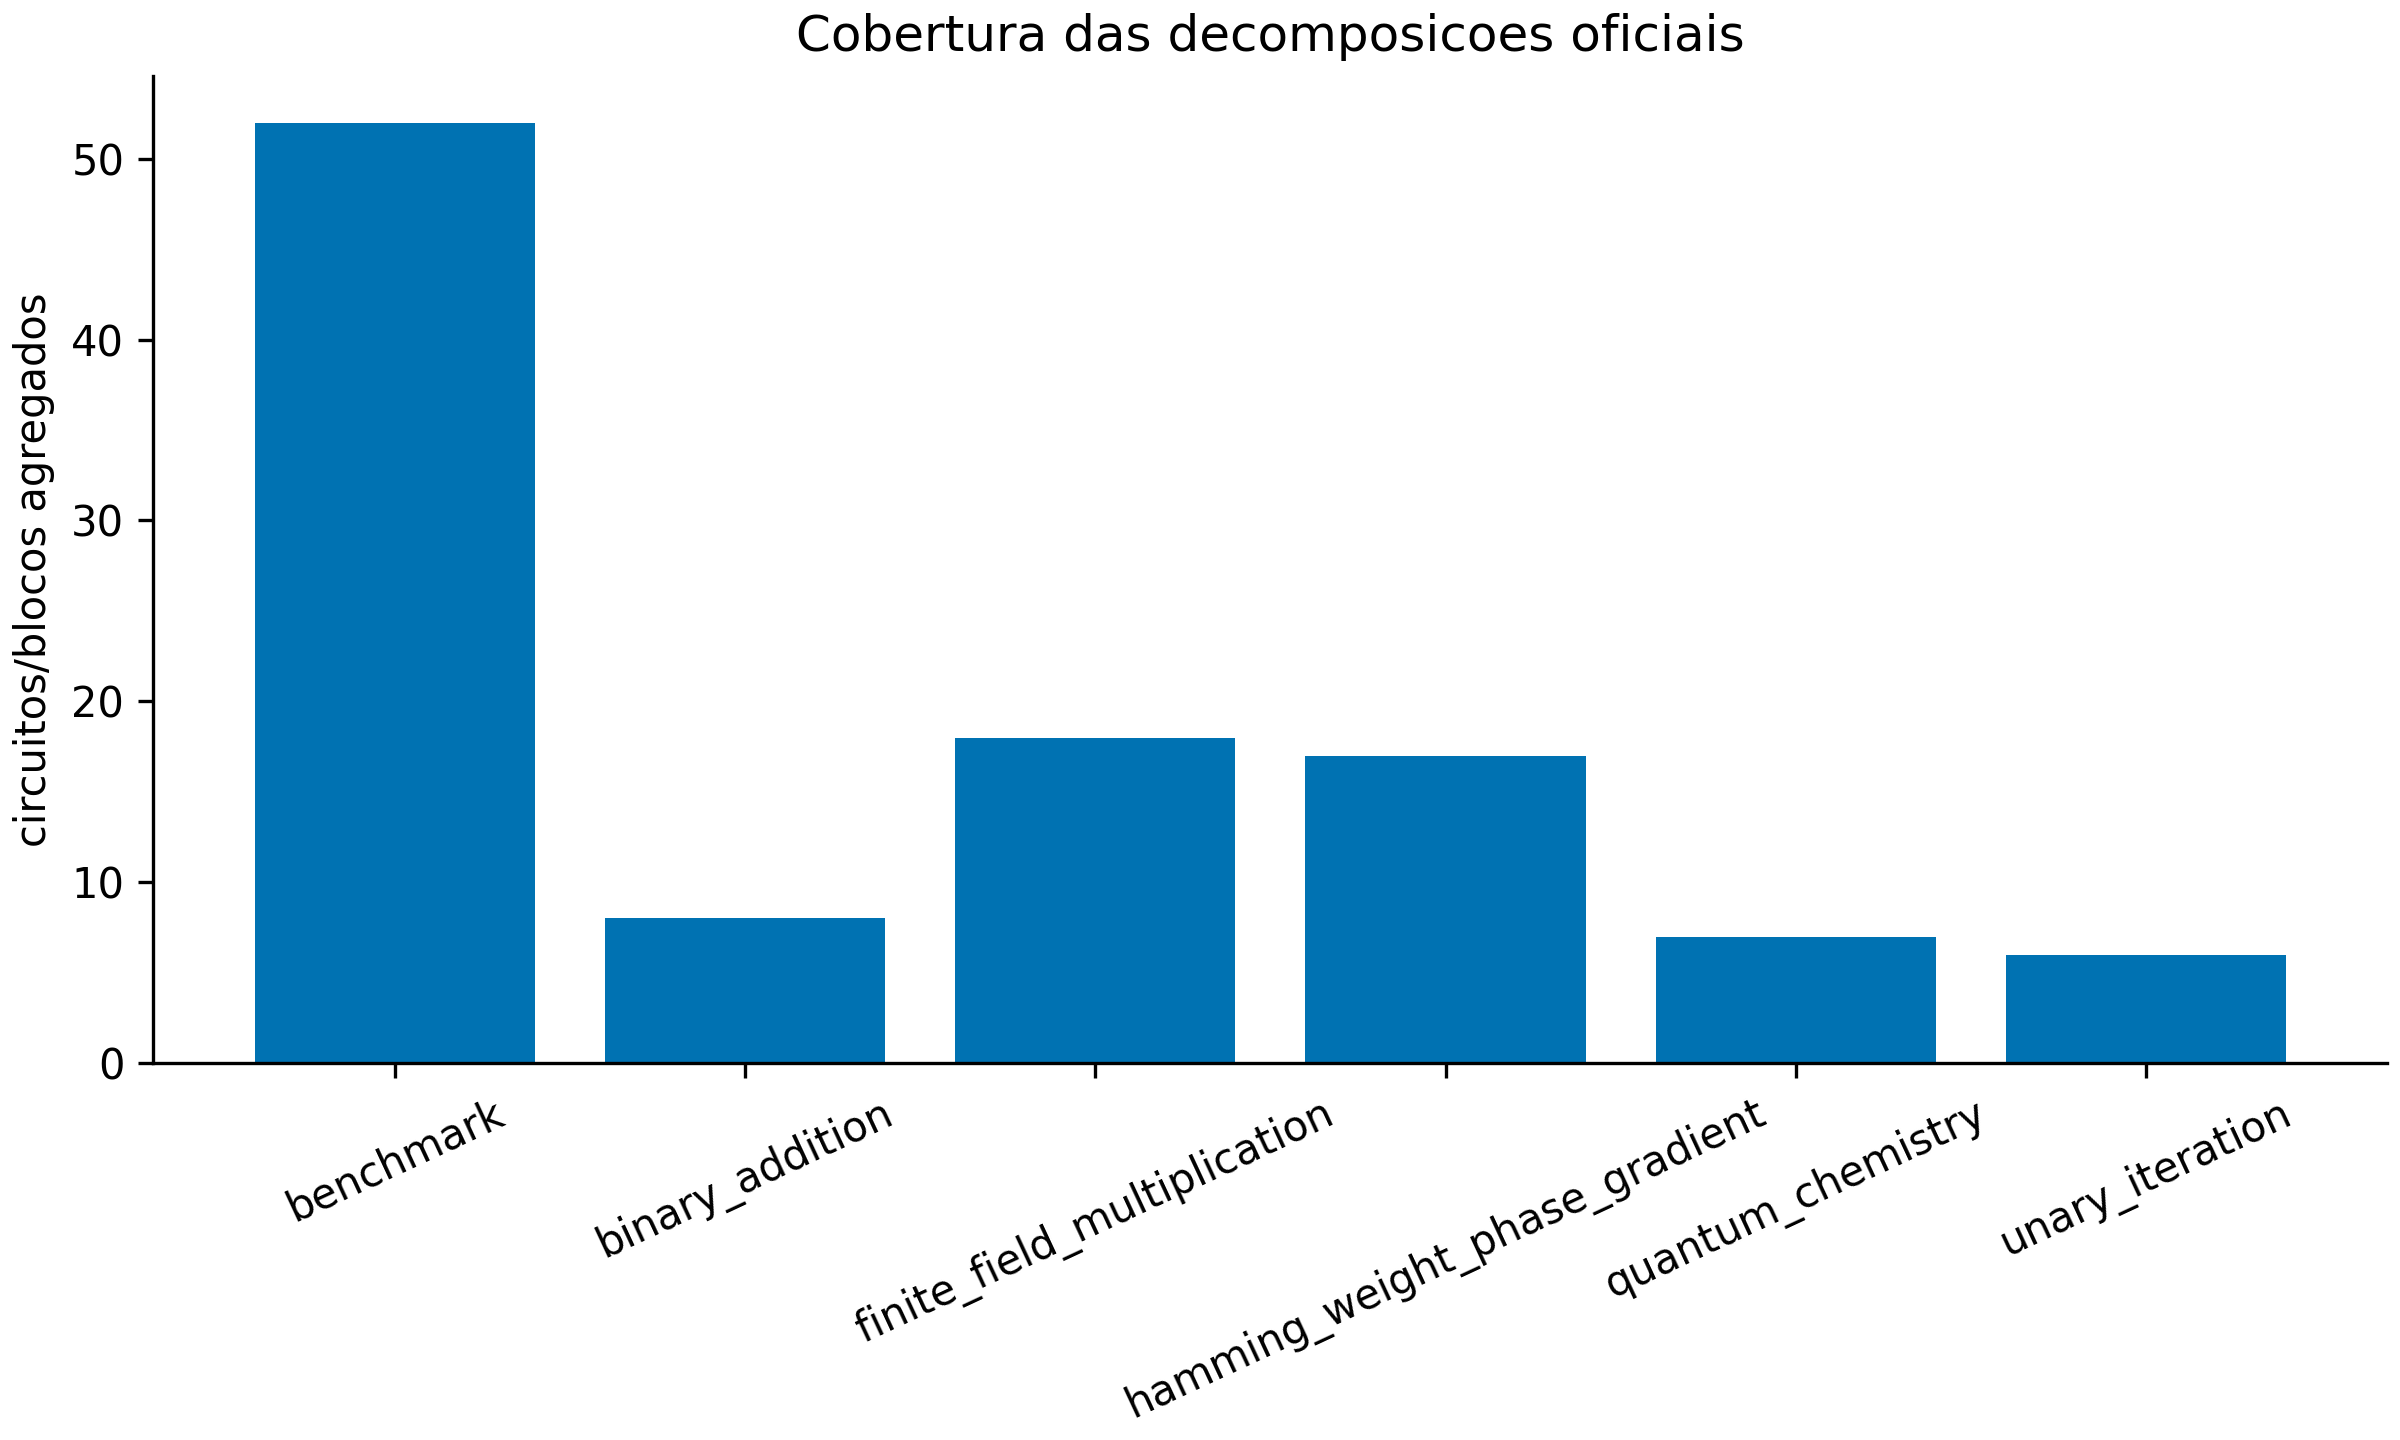

In [6]:

figure_paths = [
    PAPER_REPRO_ROOT / "figures" / "paper_benchmark_comparison.png",
    PAPER_REPRO_ROOT / "figures" / "gf_multiplication_effective_tcount.png",
    PAPER_REPRO_ROOT / "figures" / "binary_addition_effective_tcount.png",
    PAPER_REPRO_ROOT / "figures" / "paper_family_coverage.png",
]

for figure_path in figure_paths:
    display(Markdown(f"### {figure_path.name}"))
    display(Image(filename=str(figure_path)))



## 6. Baselines práticos da Entrega 1

A reprodução do artigo por decomposição/tensor é a evidência principal. Para o relatório da disciplina, também precisamos de uma tabela prática no formato **Original vs PyZX vs AlphaTensor-public**, com métricas de circuito e figuras estruturais.

A célula abaixo recompõe os artefatos finais da Entrega 1 a partir de `results/csv/final_metrics.csv`. Se quiser reconstruir esse CSV desde o início, rode antes os scripts de inventário, PyZX, replay das decomposições públicas, métricas e agregação descritos no README.


In [7]:

final_metrics = PROJECT_ROOT / "results" / "csv" / "final_metrics.csv"
assert final_metrics.exists(), (
    "results/csv/final_metrics.csv não existe. Rode os scripts de inventário, PyZX, "
    "replay_public_decompositions.py, compute_metrics.py e aggregate_results.py antes desta etapa."
)

subprocess.run([sys.executable, "scripts/make_entrega1_outputs.py"], cwd=PROJECT_ROOT, check=True)

entrega1_csv = PROJECT_ROOT / "results" / "csv" / "entrega1_metrics.csv"
entrega1_formal_csv = PROJECT_ROOT / "results" / "csv" / "entrega1_metrics_formally_verified.csv"
entrega1_df = pd.read_csv(entrega1_csv)
entrega1_formal_df = pd.read_csv(entrega1_formal_csv)

print("Tabela completa:", entrega1_csv.relative_to(PROJECT_ROOT), entrega1_df.shape)
print("Tabela formal sem timeouts:", entrega1_formal_csv.relative_to(PROJECT_ROOT), entrega1_formal_df.shape)

display(entrega1_df[[
    "circuit_id", "method_label", "source_method", "method_status", "tcount_after",
    "tdepth_after", "depth_after", "active_t_qubits", "nonclifford_core_layers",
    "heuristic_splitting_score", "formal_verification_status"
]].head(18))


{'output_csv': '/Users/caio/Deep-Learning/project/results/csv/entrega1_metrics.csv', 'output_json': '/Users/caio/Deep-Learning/project/results/csv/entrega1_metrics.json', 'formal_output_csv': '/Users/caio/Deep-Learning/project/results/csv/entrega1_metrics_formally_verified.csv', 'formal_output_json': '/Users/caio/Deep-Learning/project/results/csv/entrega1_metrics_formally_verified.json', 'figure_dir': '/Users/caio/Deep-Learning/project/results/figures/entrega1', 'formal_figure_dir': '/Users/caio/Deep-Learning/project/results/figures/entrega1_formal', 'report_path': '/Users/caio/Deep-Learning/project/results/reports/entrega1_experimental_summary.md', 'formal_report_path': '/Users/caio/Deep-Learning/project/results/reports/entrega1_formally_verified_summary.md', 'heatmaps': ['/Users/caio/Deep-Learning/project/results/figures/entrega1/t_gate_heatmap_mod_5_4.png', '/Users/caio/Deep-Learning/project/results/figures/entrega1/t_gate_heatmap_qft_4.png', '/Users/caio/Deep-Learning/project/resul

,circuit_id,method_label,source_method,method_status,tcount_after,tdepth_after,depth_after,active_t_qubits,nonclifford_core_layers,heuristic_splitting_score,formal_verification_status
0,mod_5_4,Original,original,ok,28,16,59,5,50,0.039349,not-applicable
1,mod_5_4,PyZX,pyzx,ok,8,2,45,4,31,0.120323,equal
2,mod_5_4,AlphaTensor-public,public_resynth_no_gadgets,ok,7,4,57,3,27,0.241598,equal
3,gf_2pow2_mult,Original,original,ok,28,8,42,6,39,0.033455,not-applicable
4,gf_2pow2_mult,PyZX,pyzx,ok,18,4,111,6,85,0.039491,equal
5,gf_2pow2_mult,AlphaTensor-public,public_resynth_no_gadgets,ok,17,6,161,5,73,0.202483,equal
6,cuccaro_adder_n3,Original,original,ok,42,10,73,7,66,0.029141,not-applicable
7,cuccaro_adder_n3,PyZX,pyzx,ok,16,6,110,6,79,0.136102,equal
8,cuccaro_adder_n3,AlphaTensor-public,public_resynth_gadgets,ok,14,4,242,5,38,0.385191,inconclusive
9,qft_4,Original,original,ok,69,40,152,5,150,0.021032,not-applicable



## 7. Métricas estruturais Clifford/non-Clifford

As métricas abaixo são proxies simples, adequadas para a Entrega 1:

- `active_t_qubits`: número de qubits tocados por portas `T/Tdg`;
- `nonclifford_core_layers`: span temporal entre a primeira e a última porta não-Clifford;
- `nonclifford_core_area`: área qubits × camadas do núcleo não-Clifford;
- `clifford_prefix_ratio` e `clifford_suffix_ratio`: fração Clifford antes/depois do núcleo;
- `heuristic_splitting_score`: score heurístico de concentração/localidade.

Isso não substitui a detecção formal via ZX-calculus do artigo de Clifford splitting, mas já permite discutir que redução de T-count e concentração estrutural são dimensões diferentes.


In [8]:

summary_cols = [
    "circuit_id", "method_label", "tcount_after", "active_t_qubits",
    "nonclifford_core_layers", "nonclifford_core_area",
    "clifford_prefix_ratio", "clifford_suffix_ratio", "heuristic_splitting_score",
]
structural_df = entrega1_df[entrega1_df["method_status"] == "ok"][summary_cols].copy()
structural_df = structural_df.sort_values(["circuit_id", "method_label"])
display(structural_df)


,circuit_id,method_label,tcount_after,active_t_qubits,nonclifford_core_layers,nonclifford_core_area,clifford_prefix_ratio,clifford_suffix_ratio,heuristic_splitting_score
8,cuccaro_adder_n3,AlphaTensor-public,14,5,38,190,0.115702,0.727273,0.385191
6,cuccaro_adder_n3,Original,42,7,66,462,0.054795,0.041096,0.029141
7,cuccaro_adder_n3,PyZX,16,6,79,474,0.218182,0.063636,0.136102
5,gf_2pow2_mult,AlphaTensor-public,17,5,73,365,0.080745,0.465839,0.202483
3,gf_2pow2_mult,Original,28,6,39,234,0.047619,0.023810,0.033455
4,gf_2pow2_mult,PyZX,18,6,85,510,0.162162,0.072072,0.039491
17,hamming_15_low,AlphaTensor-public,73,11,1509,57342,0.016456,0.569665,0.423970
15,hamming_15_low,Original,161,8,275,2475,0.031546,0.100946,0.336141
16,hamming_15_low,PyZX,97,8,600,9000,0.052050,0.001577,0.227272
2,mod_5_4,AlphaTensor-public,7,3,27,135,0.070175,0.456140,0.241598



## 8. Figuras finais para a Entrega 1

Essas figuras são as mais diretas para o primeiro draft: comparação de T-count, tamanho do núcleo não-Clifford, scatter T-count vs estrutura e heatmaps de localização de portas T/Tdg.


### tcount_comparison.png

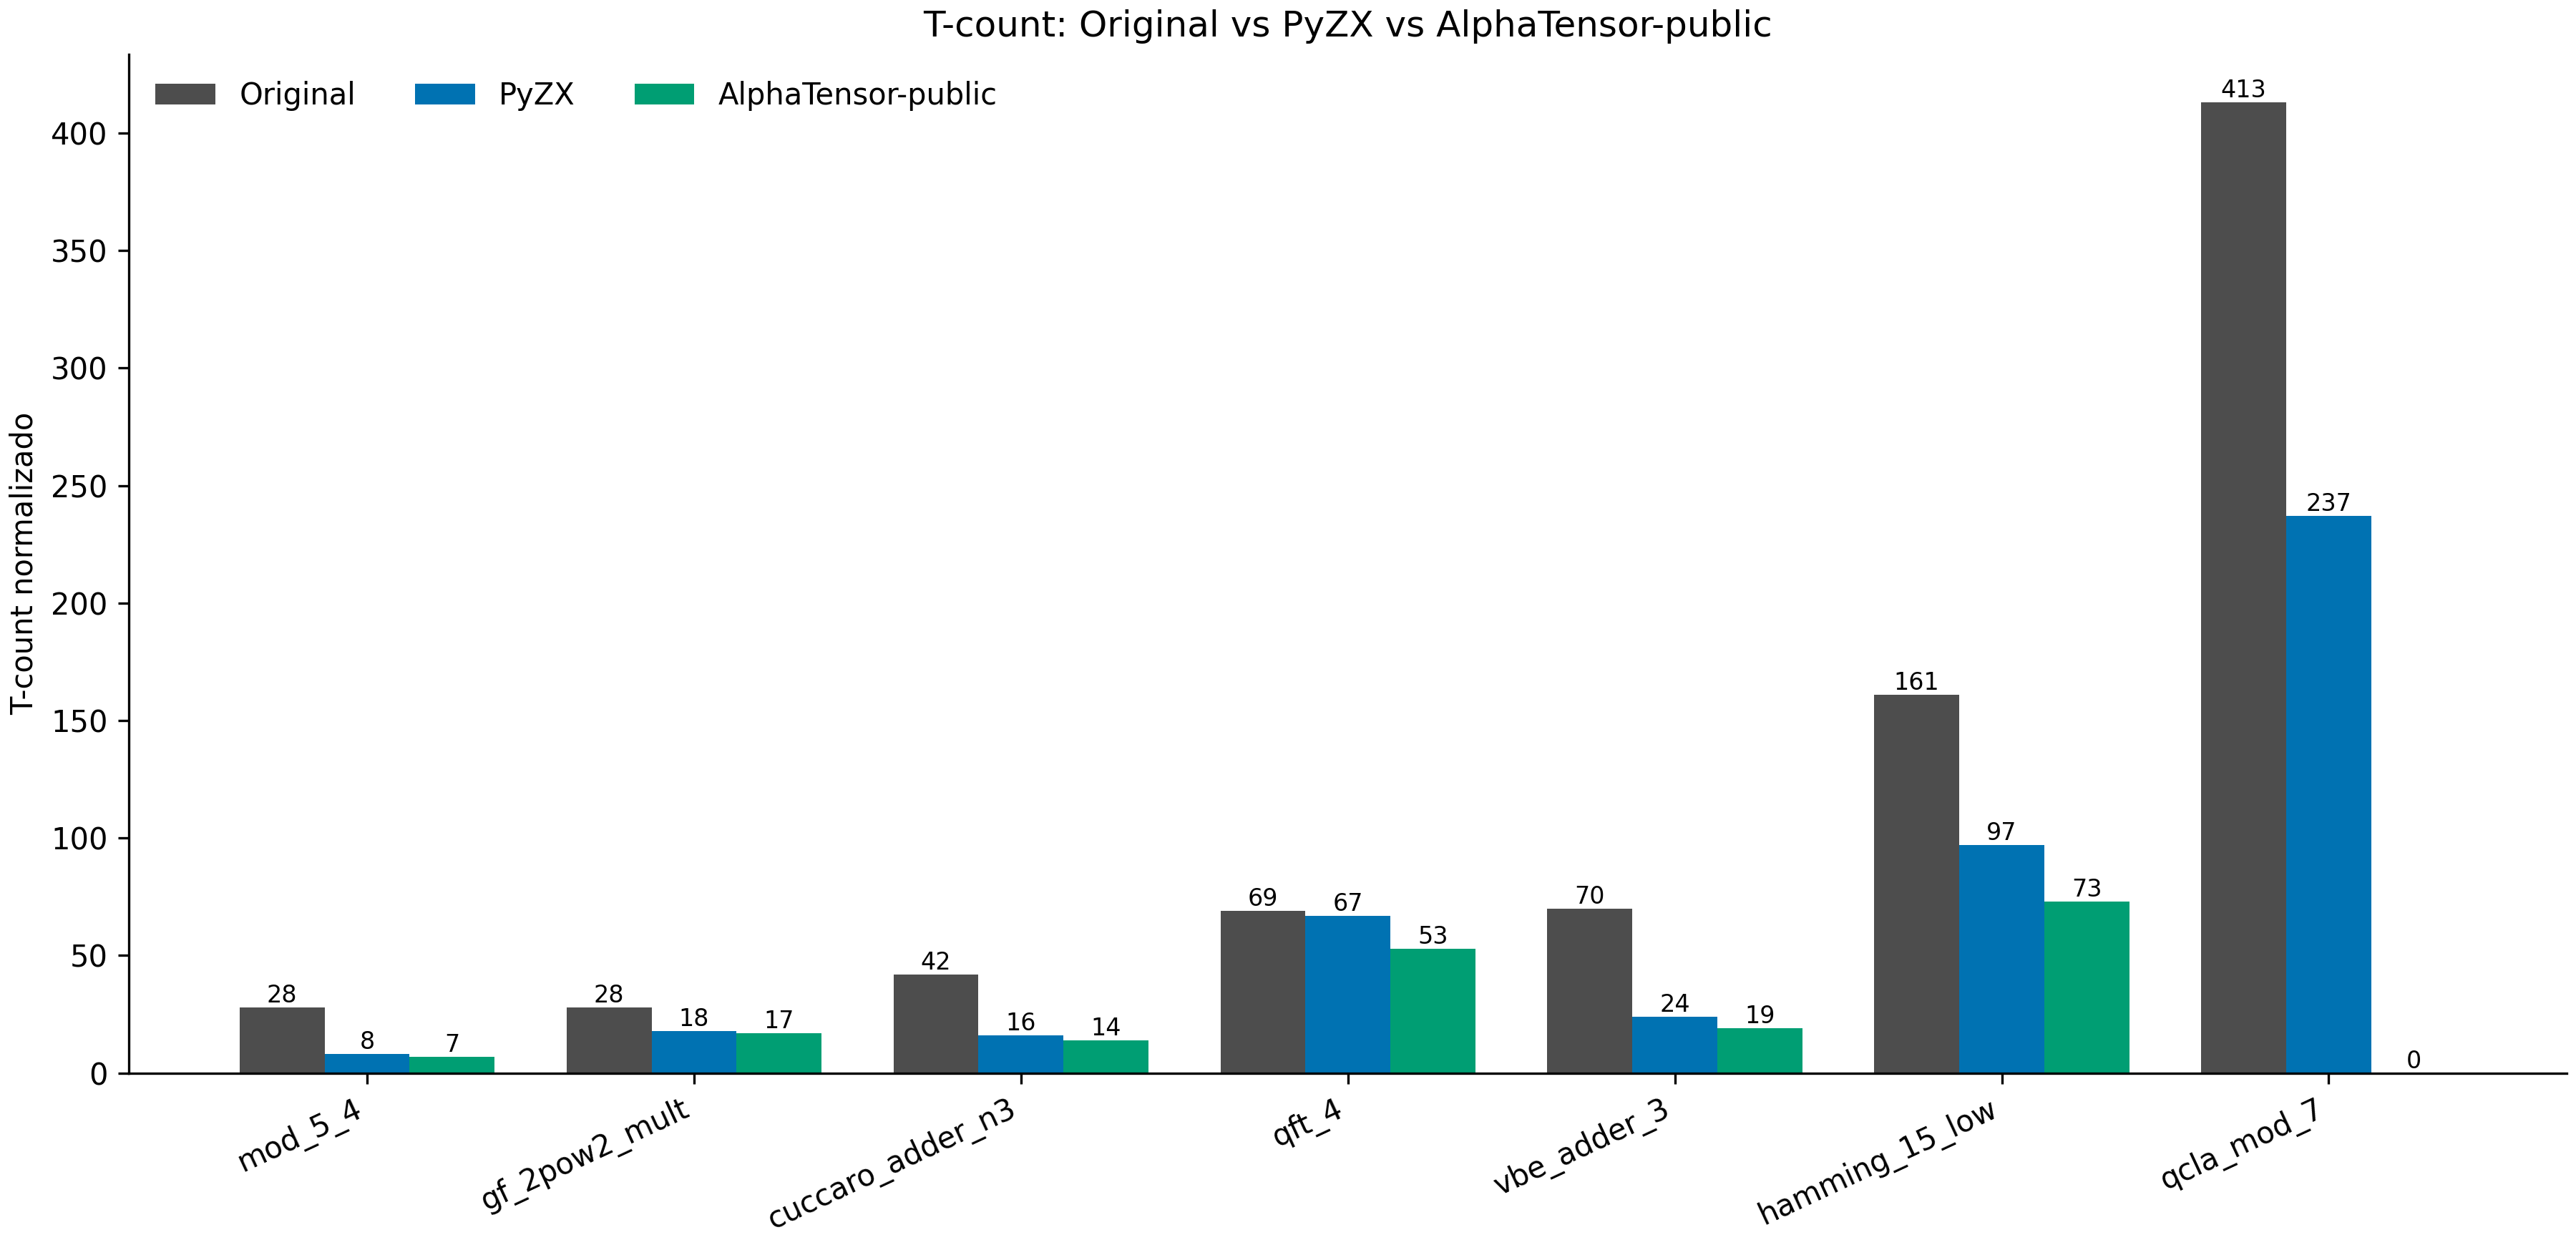

### nonclifford_core_comparison.png

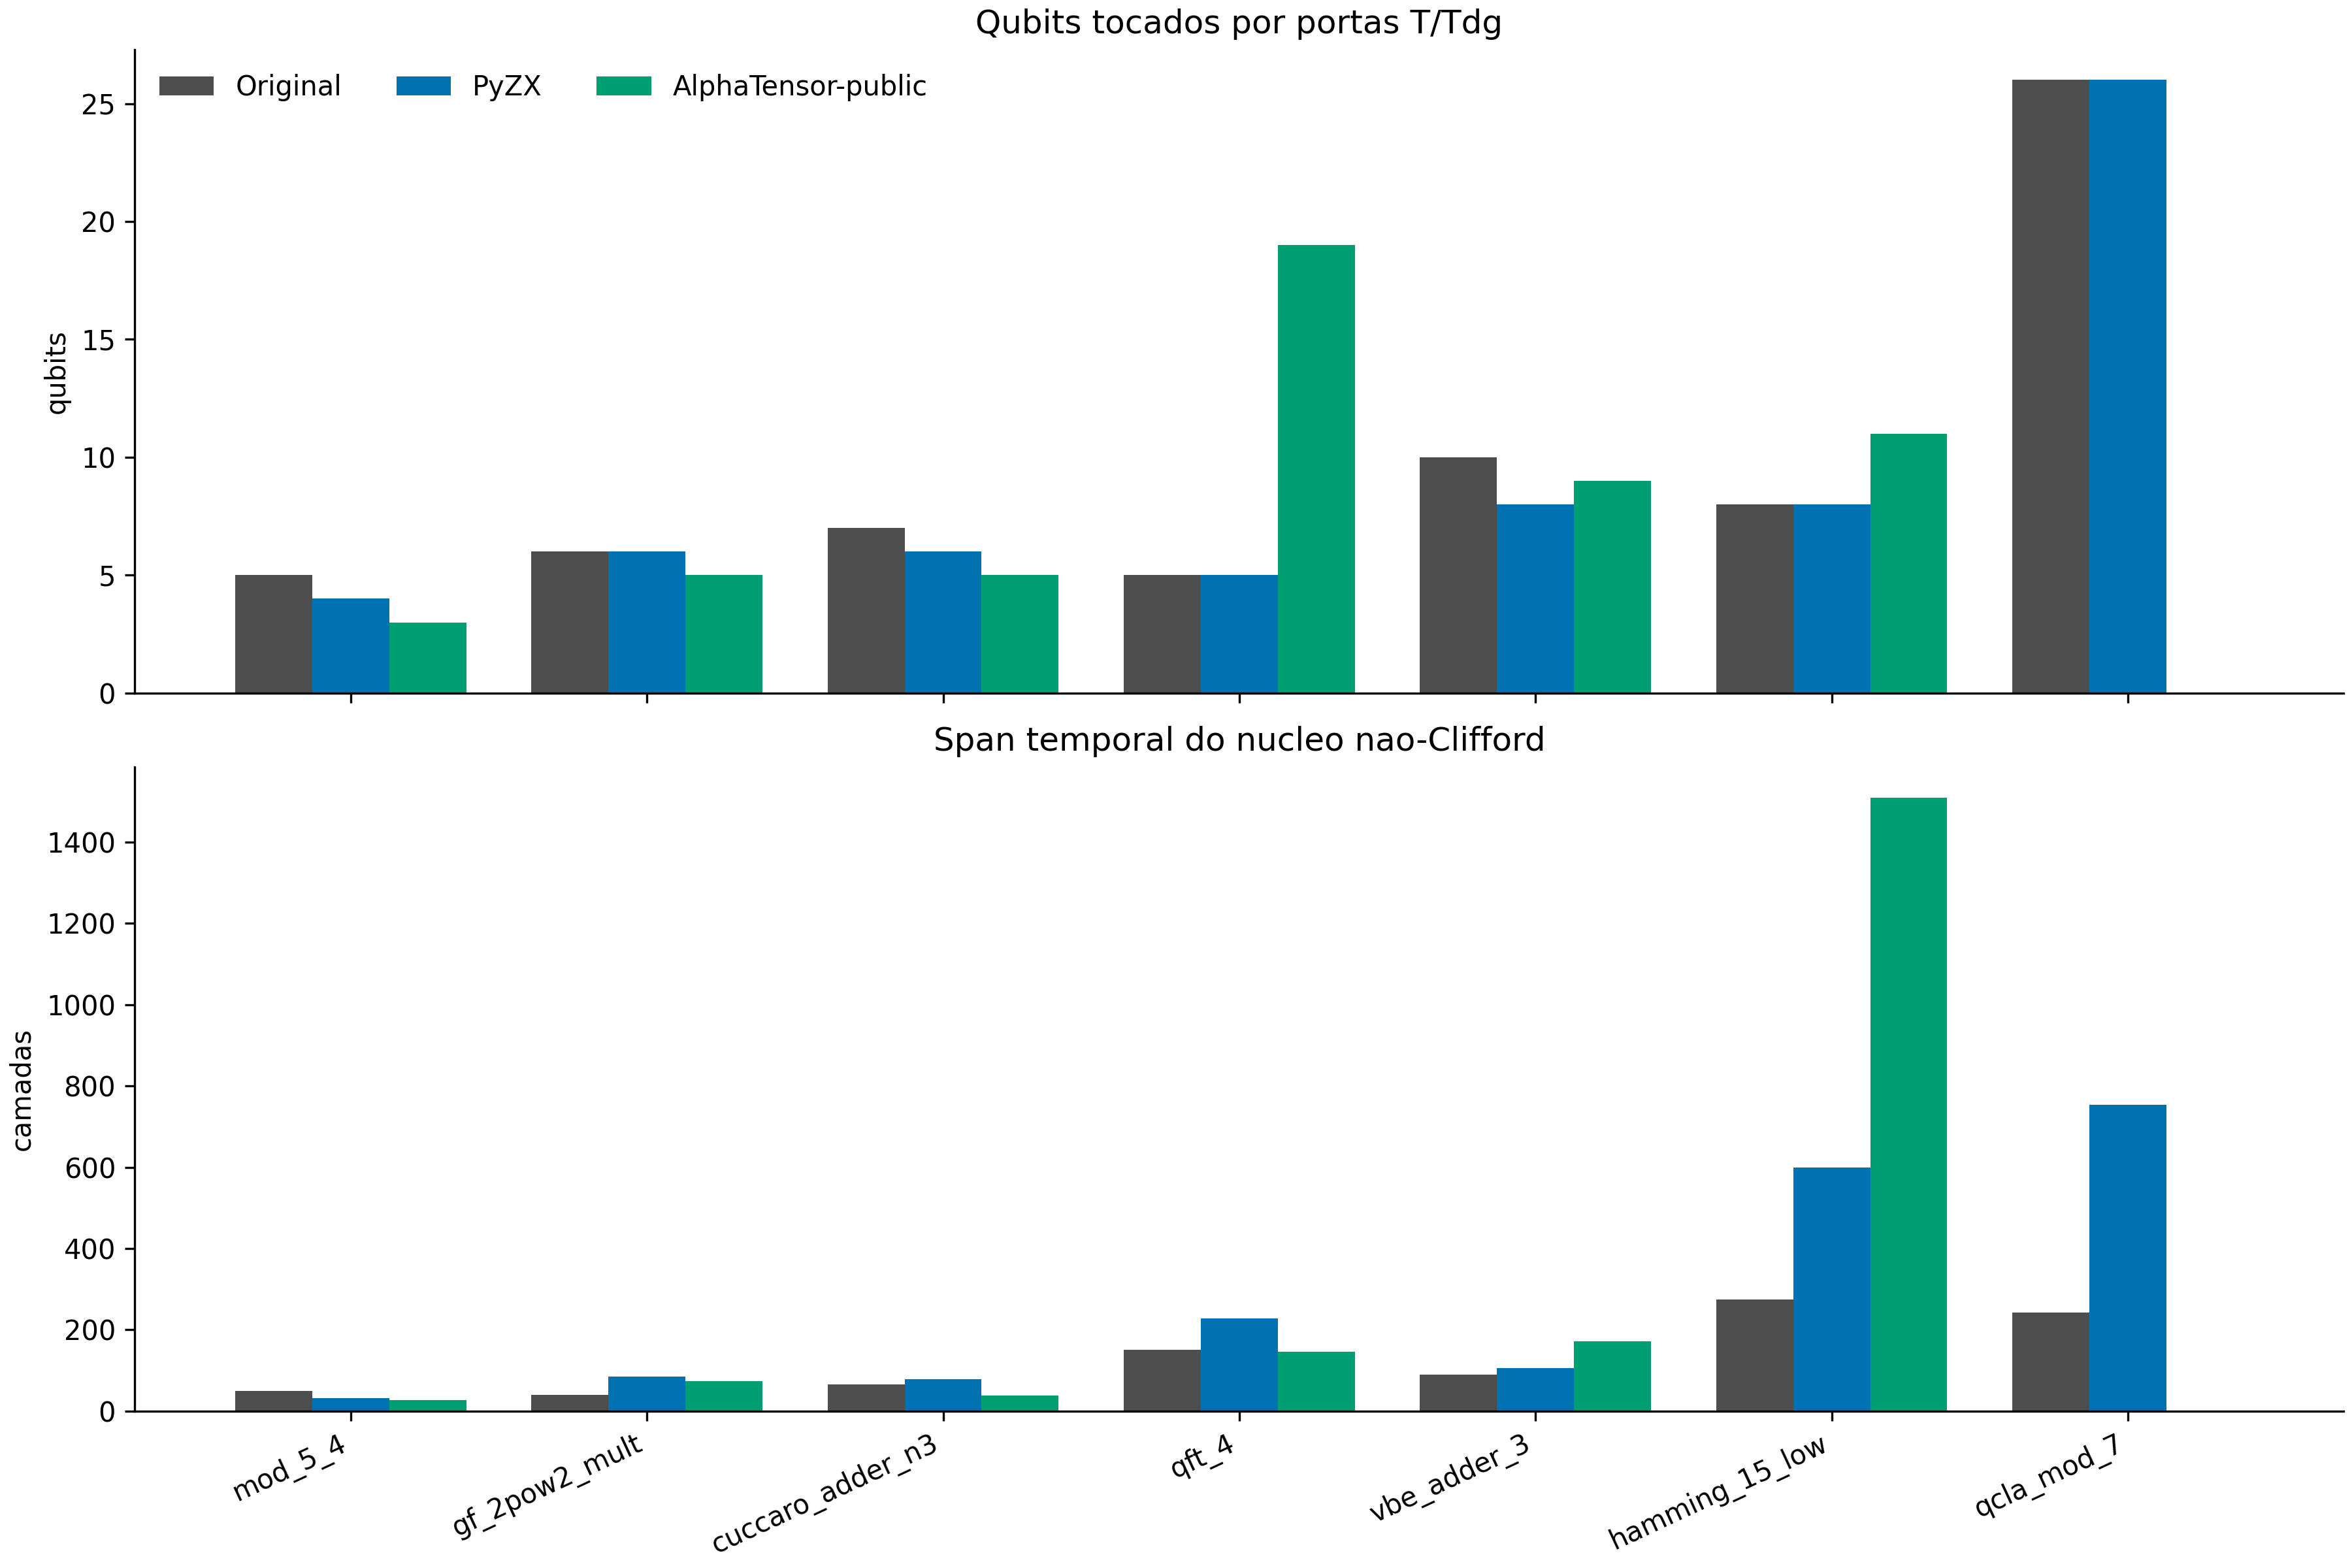

### tcount_reduction_vs_core_area.png

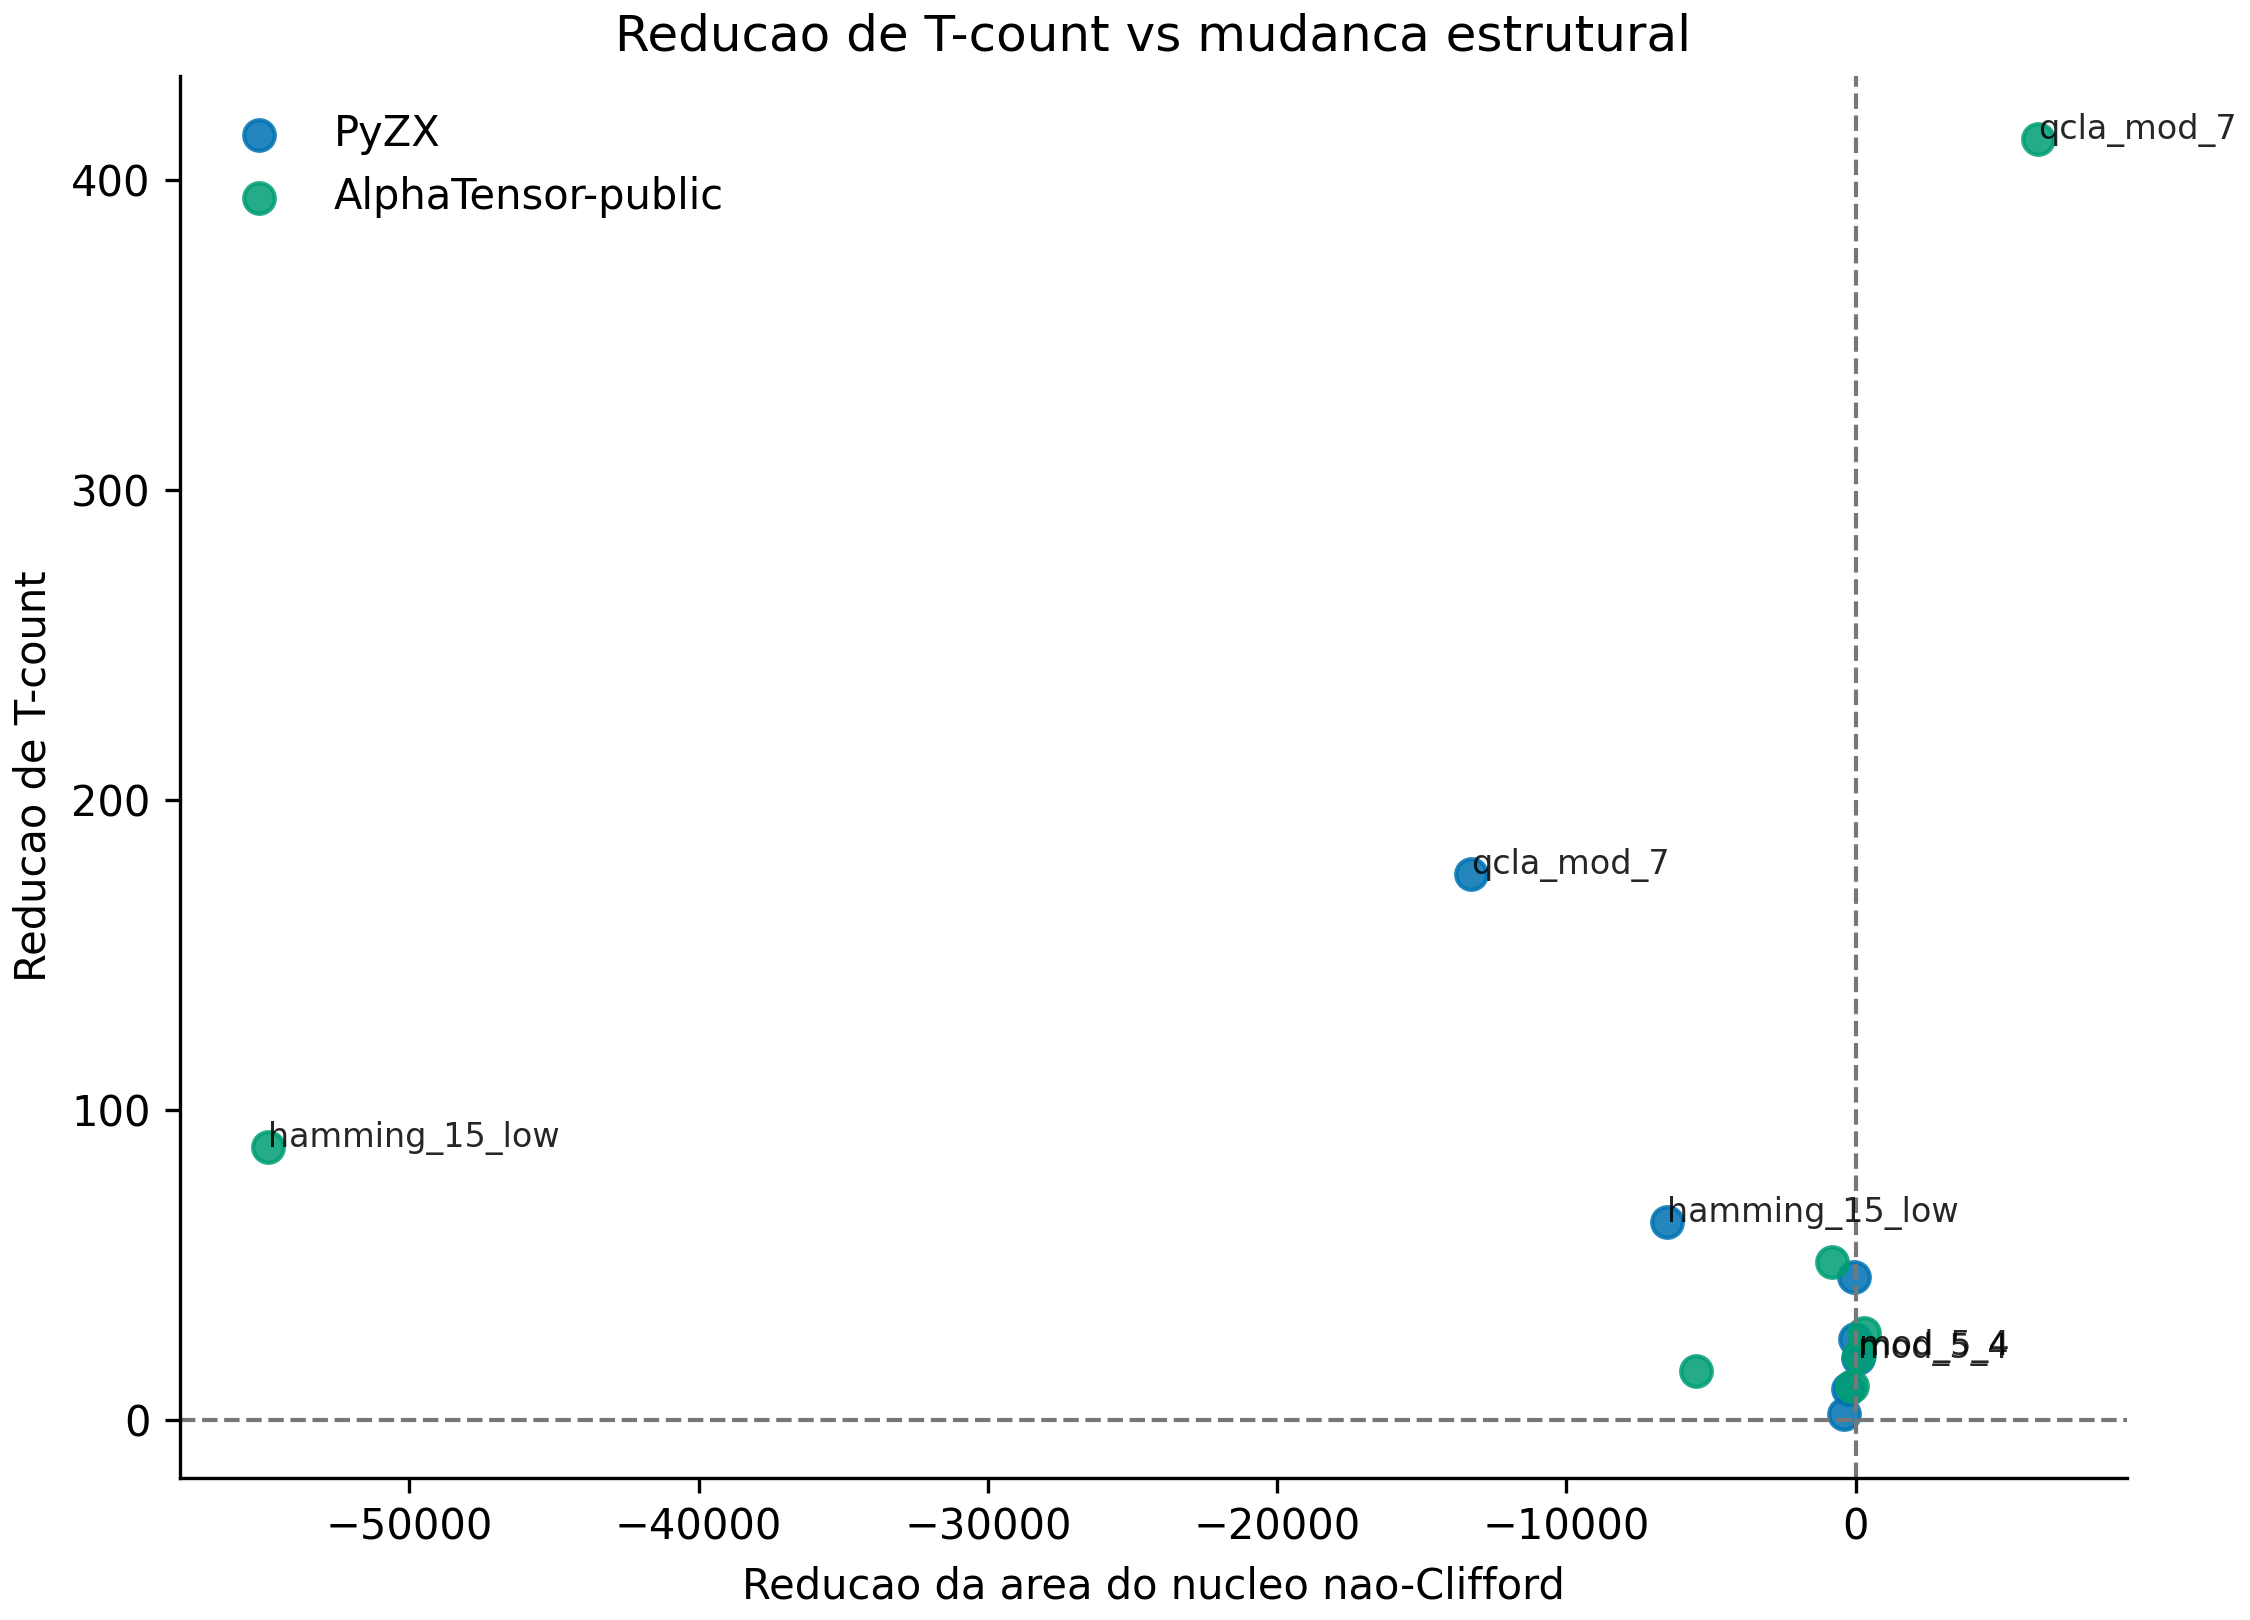

### t_gate_heatmap_mod_5_4.png

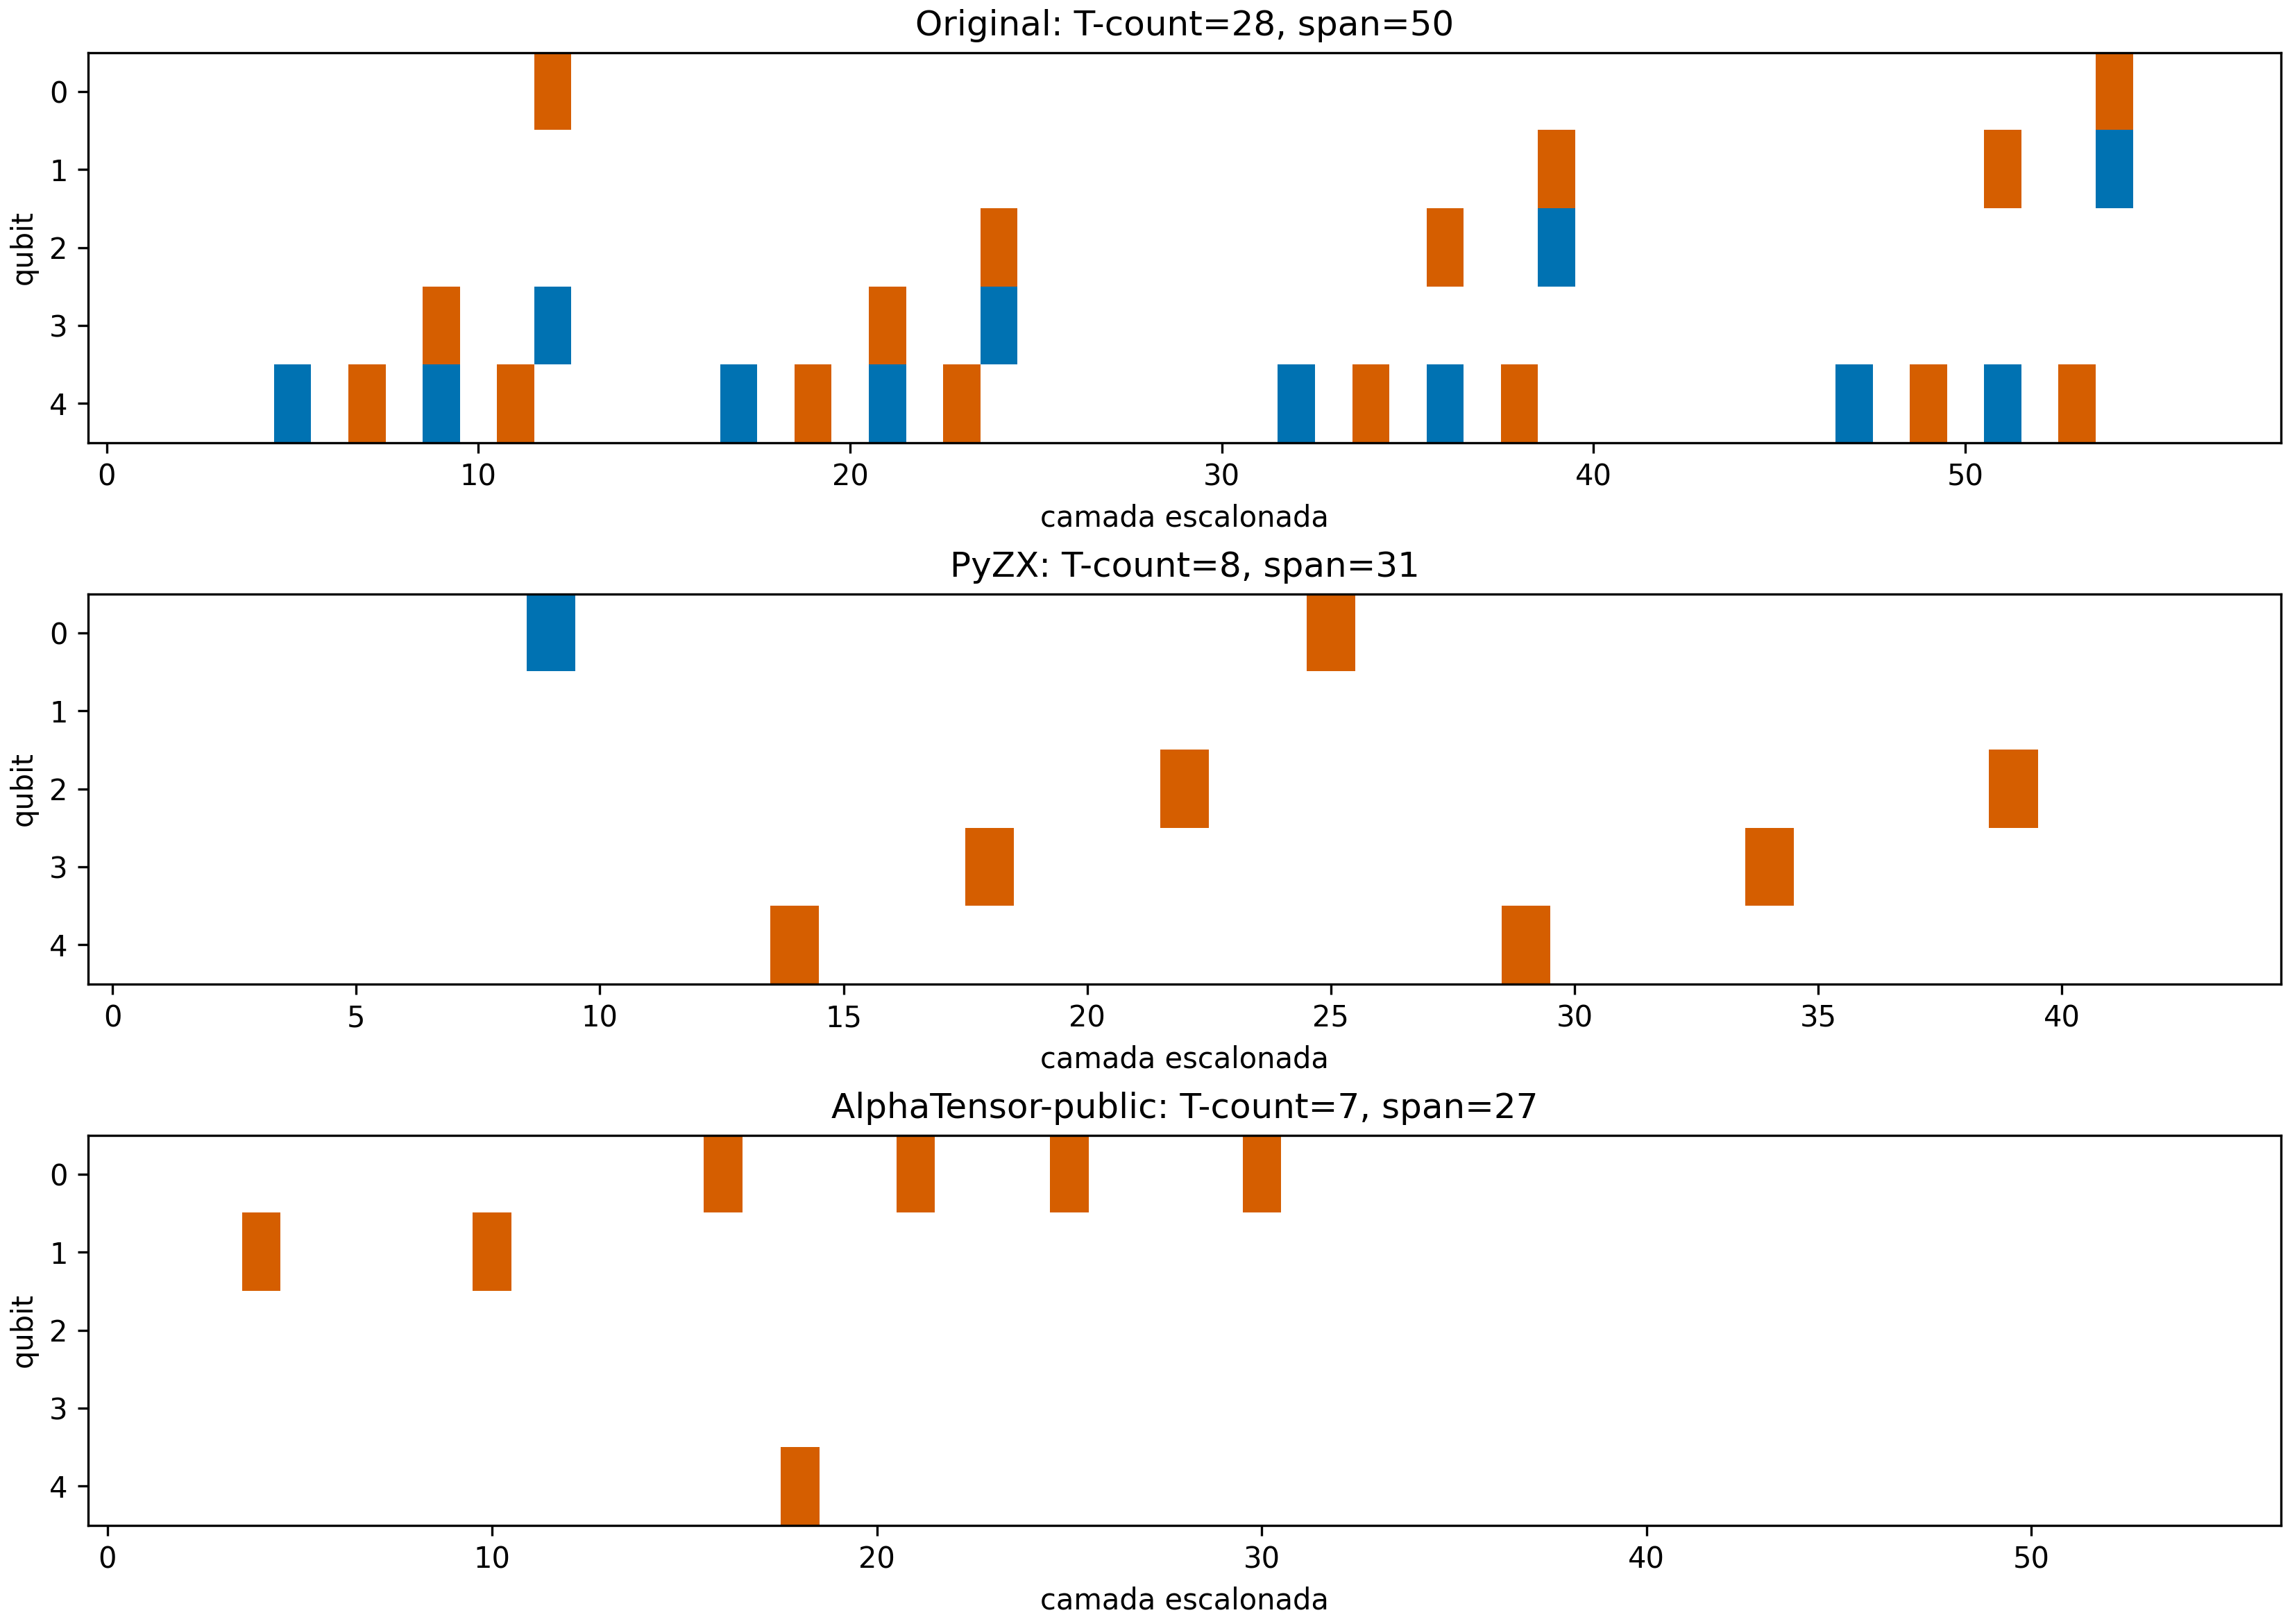

### t_gate_heatmap_qft_4.png

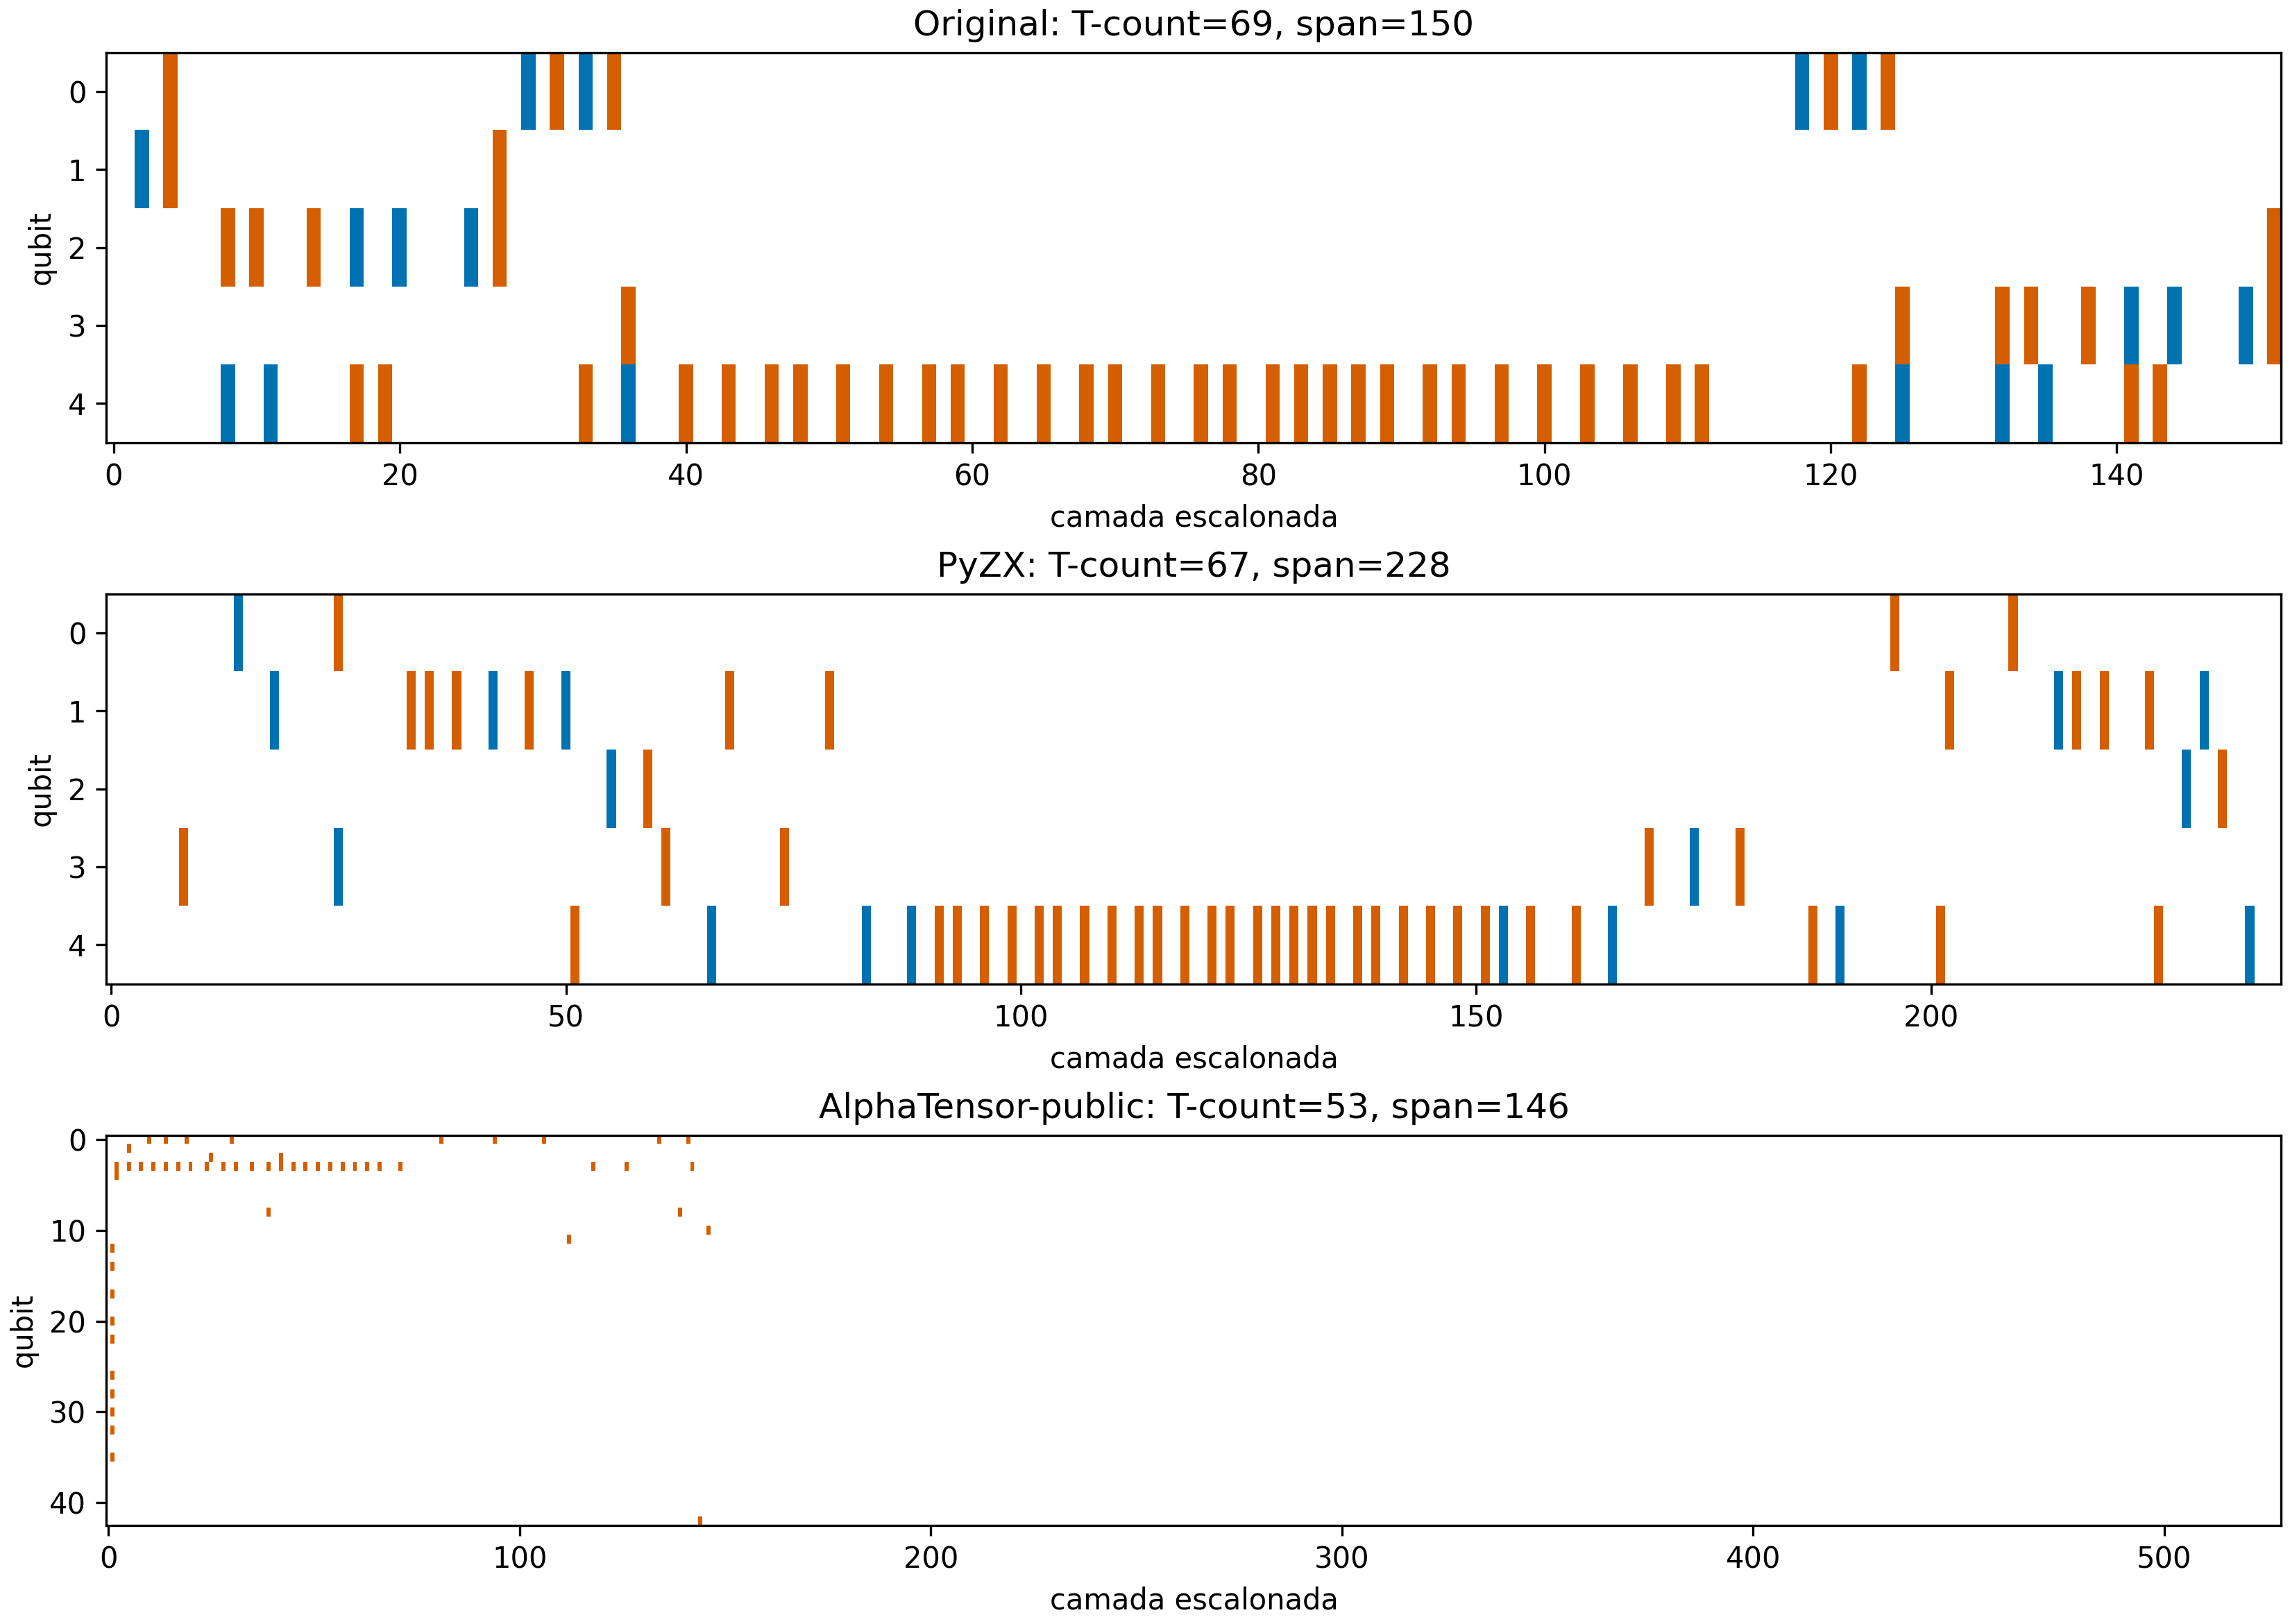

### t_gate_heatmap_vbe_adder_3.png

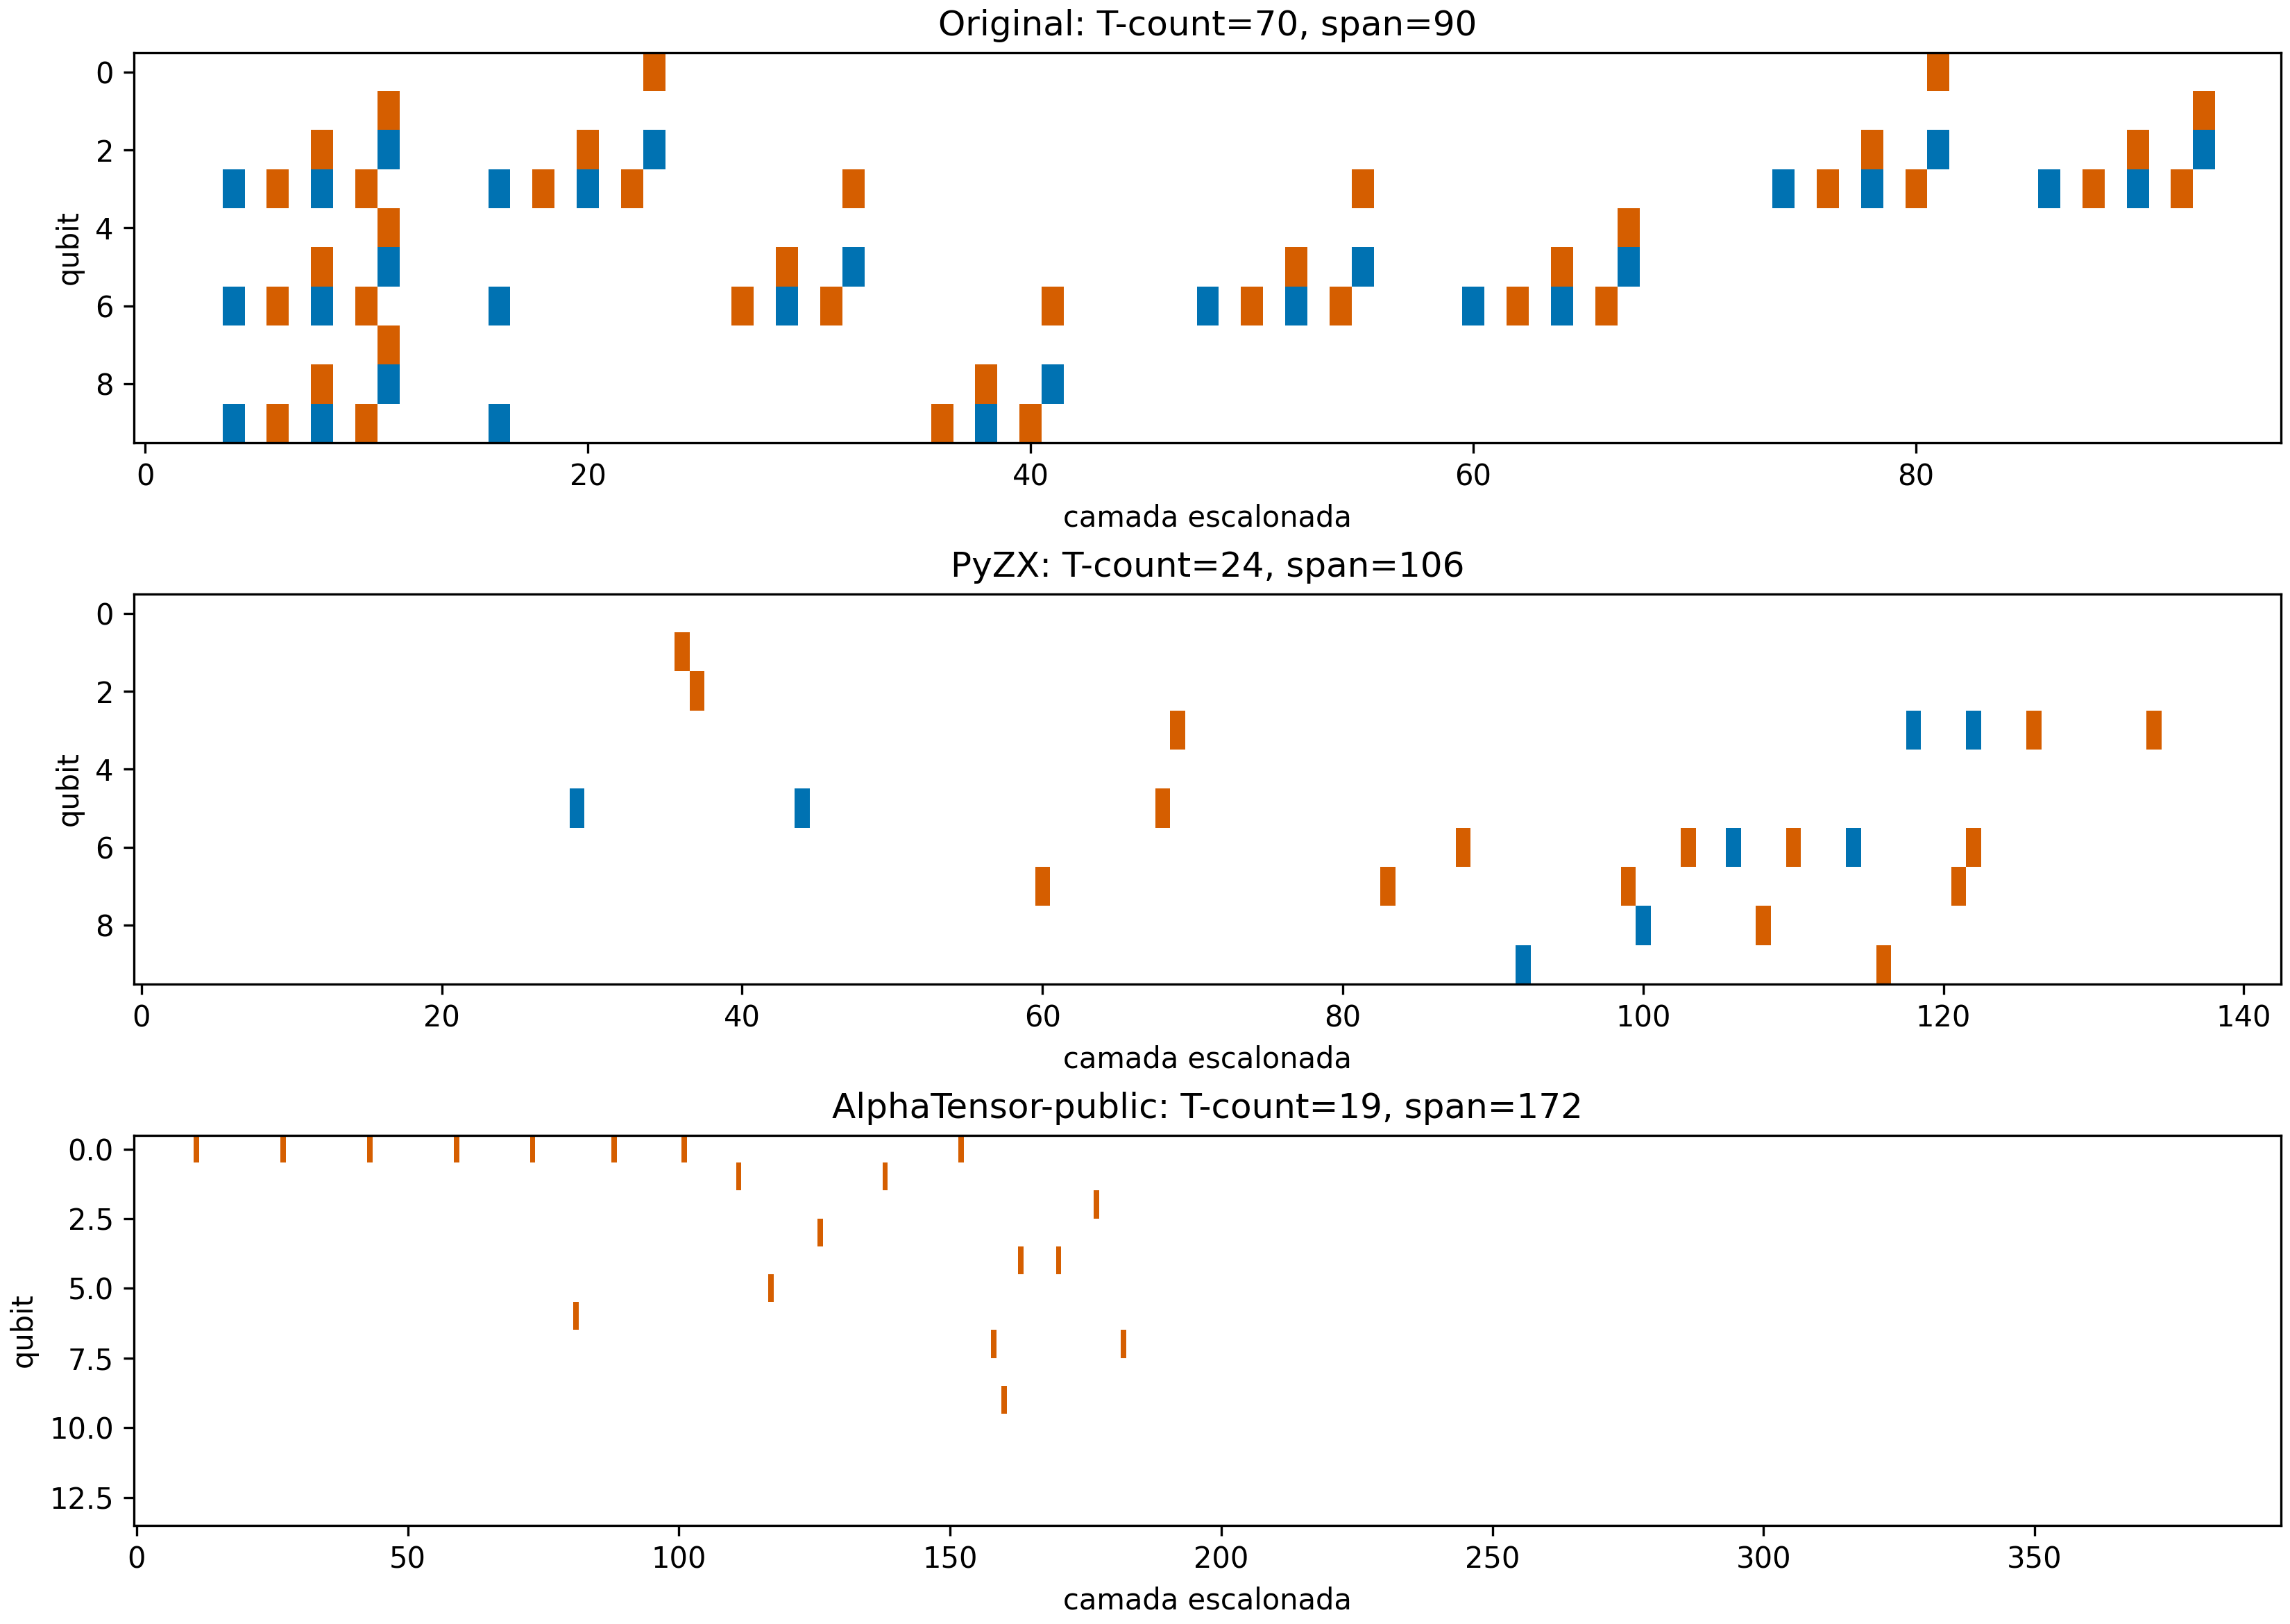

In [9]:

entrega1_figures = [
    PROJECT_ROOT / "results" / "figures" / "entrega1" / "tcount_comparison.png",
    PROJECT_ROOT / "results" / "figures" / "entrega1" / "nonclifford_core_comparison.png",
    PROJECT_ROOT / "results" / "figures" / "entrega1" / "tcount_reduction_vs_core_area.png",
    PROJECT_ROOT / "results" / "figures" / "entrega1" / "t_gate_heatmap_mod_5_4.png",
    PROJECT_ROOT / "results" / "figures" / "entrega1" / "t_gate_heatmap_qft_4.png",
    PROJECT_ROOT / "results" / "figures" / "entrega1" / "t_gate_heatmap_vbe_adder_3.png",
]

for figure_path in entrega1_figures:
    if figure_path.exists():
        display(Markdown(f"### {figure_path.name}"))
        display(Image(filename=str(figure_path)))



## 9. Verificação formal complementar

A tabela final formalmente verificada fica em `results/csv/entrega1_metrics_formally_verified.csv`. Ela remove candidatos com `timeout`, `inconclusive` ou qualquer status diferente de `equal`.

A validação principal da reprodução do artigo continua sendo a igualdade tensorial das decomposições oficiais, porque é exatamente nesse nível que os resultados públicos do AlphaTensor-Quantum são disponibilizados. A verificação formal em QASM é uma auditoria complementar sobre os circuitos reconstruídos localmente.


In [10]:

formal_cols = [
    "circuit_id", "method_label", "source_method", "tcount_after",
    "formal_verification_status", "formal_proof_path",
]
if len(entrega1_formal_df):
    display(entrega1_formal_df[formal_cols])
else:
    print("Nenhuma linha formalmente verificada disponível ainda.")

formal_report = PROJECT_ROOT / "results" / "reports" / "formal_verification_entrega1_summary.md"
if formal_report.exists():
    print(formal_report.read_text(encoding="utf-8")[:2500])
else:
    print("Relatório formal ainda não gerado. Para atualizar: uv run python scripts/run_formal_verification.py --scope entrega1 --timeout-sec 30")


,circuit_id,method_label,source_method,tcount_after,formal_verification_status,formal_proof_path
0,cuccaro_adder_n3,Original,original,42,not-applicable,NaN
1,cuccaro_adder_n3,PyZX,pyzx,16,equal,results/verification/entrega1/proofs/cuccaro_a...
2,gf_2pow2_mult,Original,original,28,not-applicable,NaN
3,gf_2pow2_mult,PyZX,pyzx,18,equal,results/verification/entrega1/proofs/gf_2pow2_...
4,gf_2pow2_mult,AlphaTensor-public,public_resynth_no_gadgets,17,equal,results/verification/entrega1/proofs/gf_2pow2_...
5,mod_5_4,Original,original,28,not-applicable,NaN
6,mod_5_4,PyZX,pyzx,8,equal,results/verification/entrega1/proofs/mod_5_4/p...
7,mod_5_4,AlphaTensor-public,public_resynth_no_gadgets,7,equal,results/verification/entrega1/proofs/mod_5_4/p...
8,qft_4,Original,original,69,not-applicable,NaN
9,qft_4,PyZX,pyzx,67,equal,results/verification/entrega1/proofs/qft_4/pyz...


# Formal Verification Summary

- Scope: `entrega1`.
- Total verification tasks: 34.
- Equal: 21.
- inconclusive: 5
- timeout: 8

## Non-equal or inconclusive cases

- `cuccaro_adder_n3` / `public_resynth_gadgets`: inconclusive - Inconclusive (took 0.011s); proof: `results/verification/entrega1/proofs/cuccaro_adder_n3/public_resynth_gadgets.verify.txt`
- `hamming_15_low` / `compile_no_quizx`: inconclusive - Inconclusive (took 12.628s); proof: `results/verification/entrega1/proofs/hamming_15_low/compile_no_quizx.verify.txt`
- `hamming_15_low` / `public_resynth_gadgets`: timeout - Timed out after 30s.; proof: `results/verification/entrega1/proofs/hamming_15_low/public_resynth_gadgets.verify.txt`
- `hamming_15_low` / `public_resynth_no_gadgets`: timeout - Timed out after 30s.; proof: `results/verification/entrega1/proofs/hamming_15_low/public_resynth_no_gadgets.verify.txt`
- `hamming_15_low` / `pyzx`: timeout - Timed out after 30s.; proof: `results/verification/entrega1/proofs/hamming_15_l


## 10. Discussão para o relatório

**O que foi fielmente reproduzido.** A reprodução principal valida as decomposições públicas do AlphaTensor-Quantum por igualdade tensorial e recalcula o T-count efetivo com gadgets. A tabela `paper_benchmark_comparison.csv` mostra `match=True` para as linhas cobertas pelo artefato público local.

**O que foi auditado, mas não é a evidência principal.** Os circuitos QASM reconstruídos, os resultados PyZX e a verificação `feynver` são úteis para aproximar a análise da disciplina de um pipeline experimental de circuitos. Porém, a reconstrução QASM não é necessariamente o formato exato usado para todos os números do artigo.

**Por que não retreinar o modelo nesta entrega.** Retreinar AlphaTensor-Quantum exigiria custo computacional alto, checkpoints/infraestrutura específicos e tempo fora do escopo incremental da Entrega 1. Para uma disciplina de Deep Learning não específica de quântica, a decisão tecnicamente defensável é reproduzir os artefatos públicos do paper e construir uma contribuição experimental própria sobre eles.

**Onde entra Clifford splitting.** A contribuição própria da Entrega 1 é medir se a parte não-Clifford fica mais concentrada/localizada depois da otimização. As métricas estruturais e heatmaps dão base para discutir casos em que T-count melhora sem que a estrutura não-Clifford melhore monotonicamente.


In [11]:

report_paths = [
    PROJECT_ROOT / "results" / "reports" / "paper_reproduction_summary.md",
    PROJECT_ROOT / "results" / "reports" / "entrega1_experimental_summary.md",
    PROJECT_ROOT / "results" / "reports" / "entrega1_formally_verified_summary.md",
]

for report_path in report_paths:
    print("-", report_path.relative_to(PROJECT_ROOT), "OK" if report_path.exists() else "missing")

print("Notebook concluído com sucesso.")


- results/reports/paper_reproduction_summary.md OK
- results/reports/entrega1_experimental_summary.md OK
- results/reports/entrega1_formally_verified_summary.md OK
Notebook concluído com sucesso.
